In [1]:
import sys
sys.path.insert(1, '../')

In [2]:
import joblib
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import precision_recall_curve, roc_curve

from functions.data import load_dataset
from functions.data import DATASETS_LS
from functions.analysis import create_df, create_fold_df
from functions.statistical_tests import apply_friedman_test, apply_nemenyi_test
from functions.plotting import compute_ylim, add_significance_bars

In [3]:
import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")
warnings.filterwarnings("ignore", message="The total space of parameters")
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

In [4]:
filename = '../models/ensembles/results'
with open(filename, 'rb') as f:
    classic_dict = pickle.load(f)

filename = '../models/ensembles/results_folds'
with open(filename, 'rb') as f:
    classic_folds_dict = pickle.load(f)

filename = '../models/basic/results'
with open(filename, 'rb') as f:
    ens_dict = pickle.load(f)

filename = '../models/basic/results_folds'
with open(filename, 'rb') as f:
    ens_folds_dict = pickle.load(f)

scores_dict = {
    key: {**classic_dict[key], **ens_dict[key]}
    for key in classic_dict
}

folds_dict = {
    key: {**classic_folds_dict[key], **ens_folds_dict[key]}
    for key in classic_folds_dict
}

In [5]:
# 37 datasets total in DATASETS_LS.
# Exclude bank-marketing (not used in the book) and page-blocks-1-3_vs_4 (pages block).
EXCLUDE = {"bank-marketing", "page-blocks-1-3_vs_4"}
datasets = [d for d in DATASETS_LS if d not in EXCLUDE]
print(f"{len(datasets)} datasets:", datasets)

35 datasets: ['abalone_19', 'car_eval_4', 'coil_2000', 'ecoli', 'isolet', 'letter_img', 'libras_move', 'mammography', 'oil', 'optical_digits', 'ozone_level', 'pen_digits', 'protein_homo', 'satimage', 'scene', 'sick_euthyroid', 'solar_flare_m0', 'spectrometer', 'thyroid_sick', 'us_crime', 'webpage', 'wine_quality', 'yeast_me2', 'cleveland-0_vs_4', 'glass-0-1-4-6_vs_2', 'led7digit-0-2-4-5-6-7-8-9_vs_1', 'pima', 'poker-8-9_vs_5', 'diabetes130', 'default_credit', 'htru2', 'credit_fraud', 'secom', 'telco', 'adult']


In [6]:
models = [
      "rf", "ada", "gbm", "cat", "lgbm", "xgb", "logit", "knn", "tree",
      ]

In [7]:
friedman_rows = []
nemenyi_dict = {}

for data in datasets:
    fold_df = create_fold_df(folds_dict, data, "roc")[models]
    statistic, pvalue = apply_friedman_test(fold_df)
    friedman_rows.append({"dataset": data, "statistic": statistic, "pvalue": pvalue})

    if pvalue < 0.05:
        nemenyi_dict[data] = apply_nemenyi_test(fold_df)

friedman_df = pd.DataFrame(friedman_rows).set_index("dataset")

In [8]:
# test function
df = create_df(scores_dict, "scene", models)
df

,roc,roc_std,ap,ap_std,precision,precision_std,recall,recall_std,f1_score,f1_std,mcc,mcc_std,ba,ba_std,brier,brier_std,gmean,gmean_std,thresh,tresh_std
rf,0.766026,0.030985,0.319567,0.057933,0.410665,0.118809,0.352857,0.104552,0.359683,0.063317,0.327593,0.058952,0.722860,0.013790,0.078553,0.003442,0.709681,0.023233,0.164677,0.032434
ada,0.726692,0.048490,0.300648,0.080888,0.423283,0.185572,0.357619,0.067114,0.360078,0.063639,0.318114,0.080905,0.686448,0.038432,0.197336,0.001778,0.680660,0.042073,0.477656,0.007483
gbm,0.782678,0.028542,0.348843,0.048426,0.347017,0.071158,0.506667,0.098945,0.398668,0.041559,0.360436,0.040115,0.734276,0.021199,0.091191,0.004067,0.730966,0.022964,0.000178,0.000114
cat,0.729634,0.050591,0.313934,0.038265,0.377880,0.033965,0.363333,0.076422,0.367114,0.046148,0.345250,0.032045,0.692482,0.035808,0.085281,0.004843,0.685591,0.037131,0.033828,0.011887
lgbm,0.802807,0.026893,0.390131,0.036634,0.415449,0.054204,0.471190,0.061392,0.436620,0.028732,0.399347,0.028447,0.749411,0.023489,0.088027,0.004628,0.741432,0.026190,0.001084,0.000743
xgb,0.799606,0.018465,0.373010,0.049088,0.391397,0.040321,0.461667,0.066660,0.419375,0.030254,0.369499,0.042481,0.729288,0.016364,0.080474,0.004560,0.720332,0.016549,0.059373,0.016123
logit,0.760837,0.033453,0.363727,0.029691,0.345646,0.063547,0.496429,0.108703,0.391113,0.032795,0.366306,0.018854,0.719132,0.033139,0.075472,0.003589,0.716034,0.033445,0.139754,0.044911
knn,0.720967,0.034893,0.278379,0.045784,0.296788,0.070448,0.530000,0.178501,0.351288,0.020681,0.308451,0.041632,0.704282,0.035623,0.078100,0.004445,0.698886,0.039862,0.155556,0.054433
tree,0.674024,0.034682,0.181514,0.025858,0.288407,0.118276,0.415476,0.172699,0.295273,0.037728,0.230260,0.052863,0.642302,0.025222,0.083523,0.003019,0.625762,0.036231,0.207438,0.080605


## Chapter 1, ensemble comparison

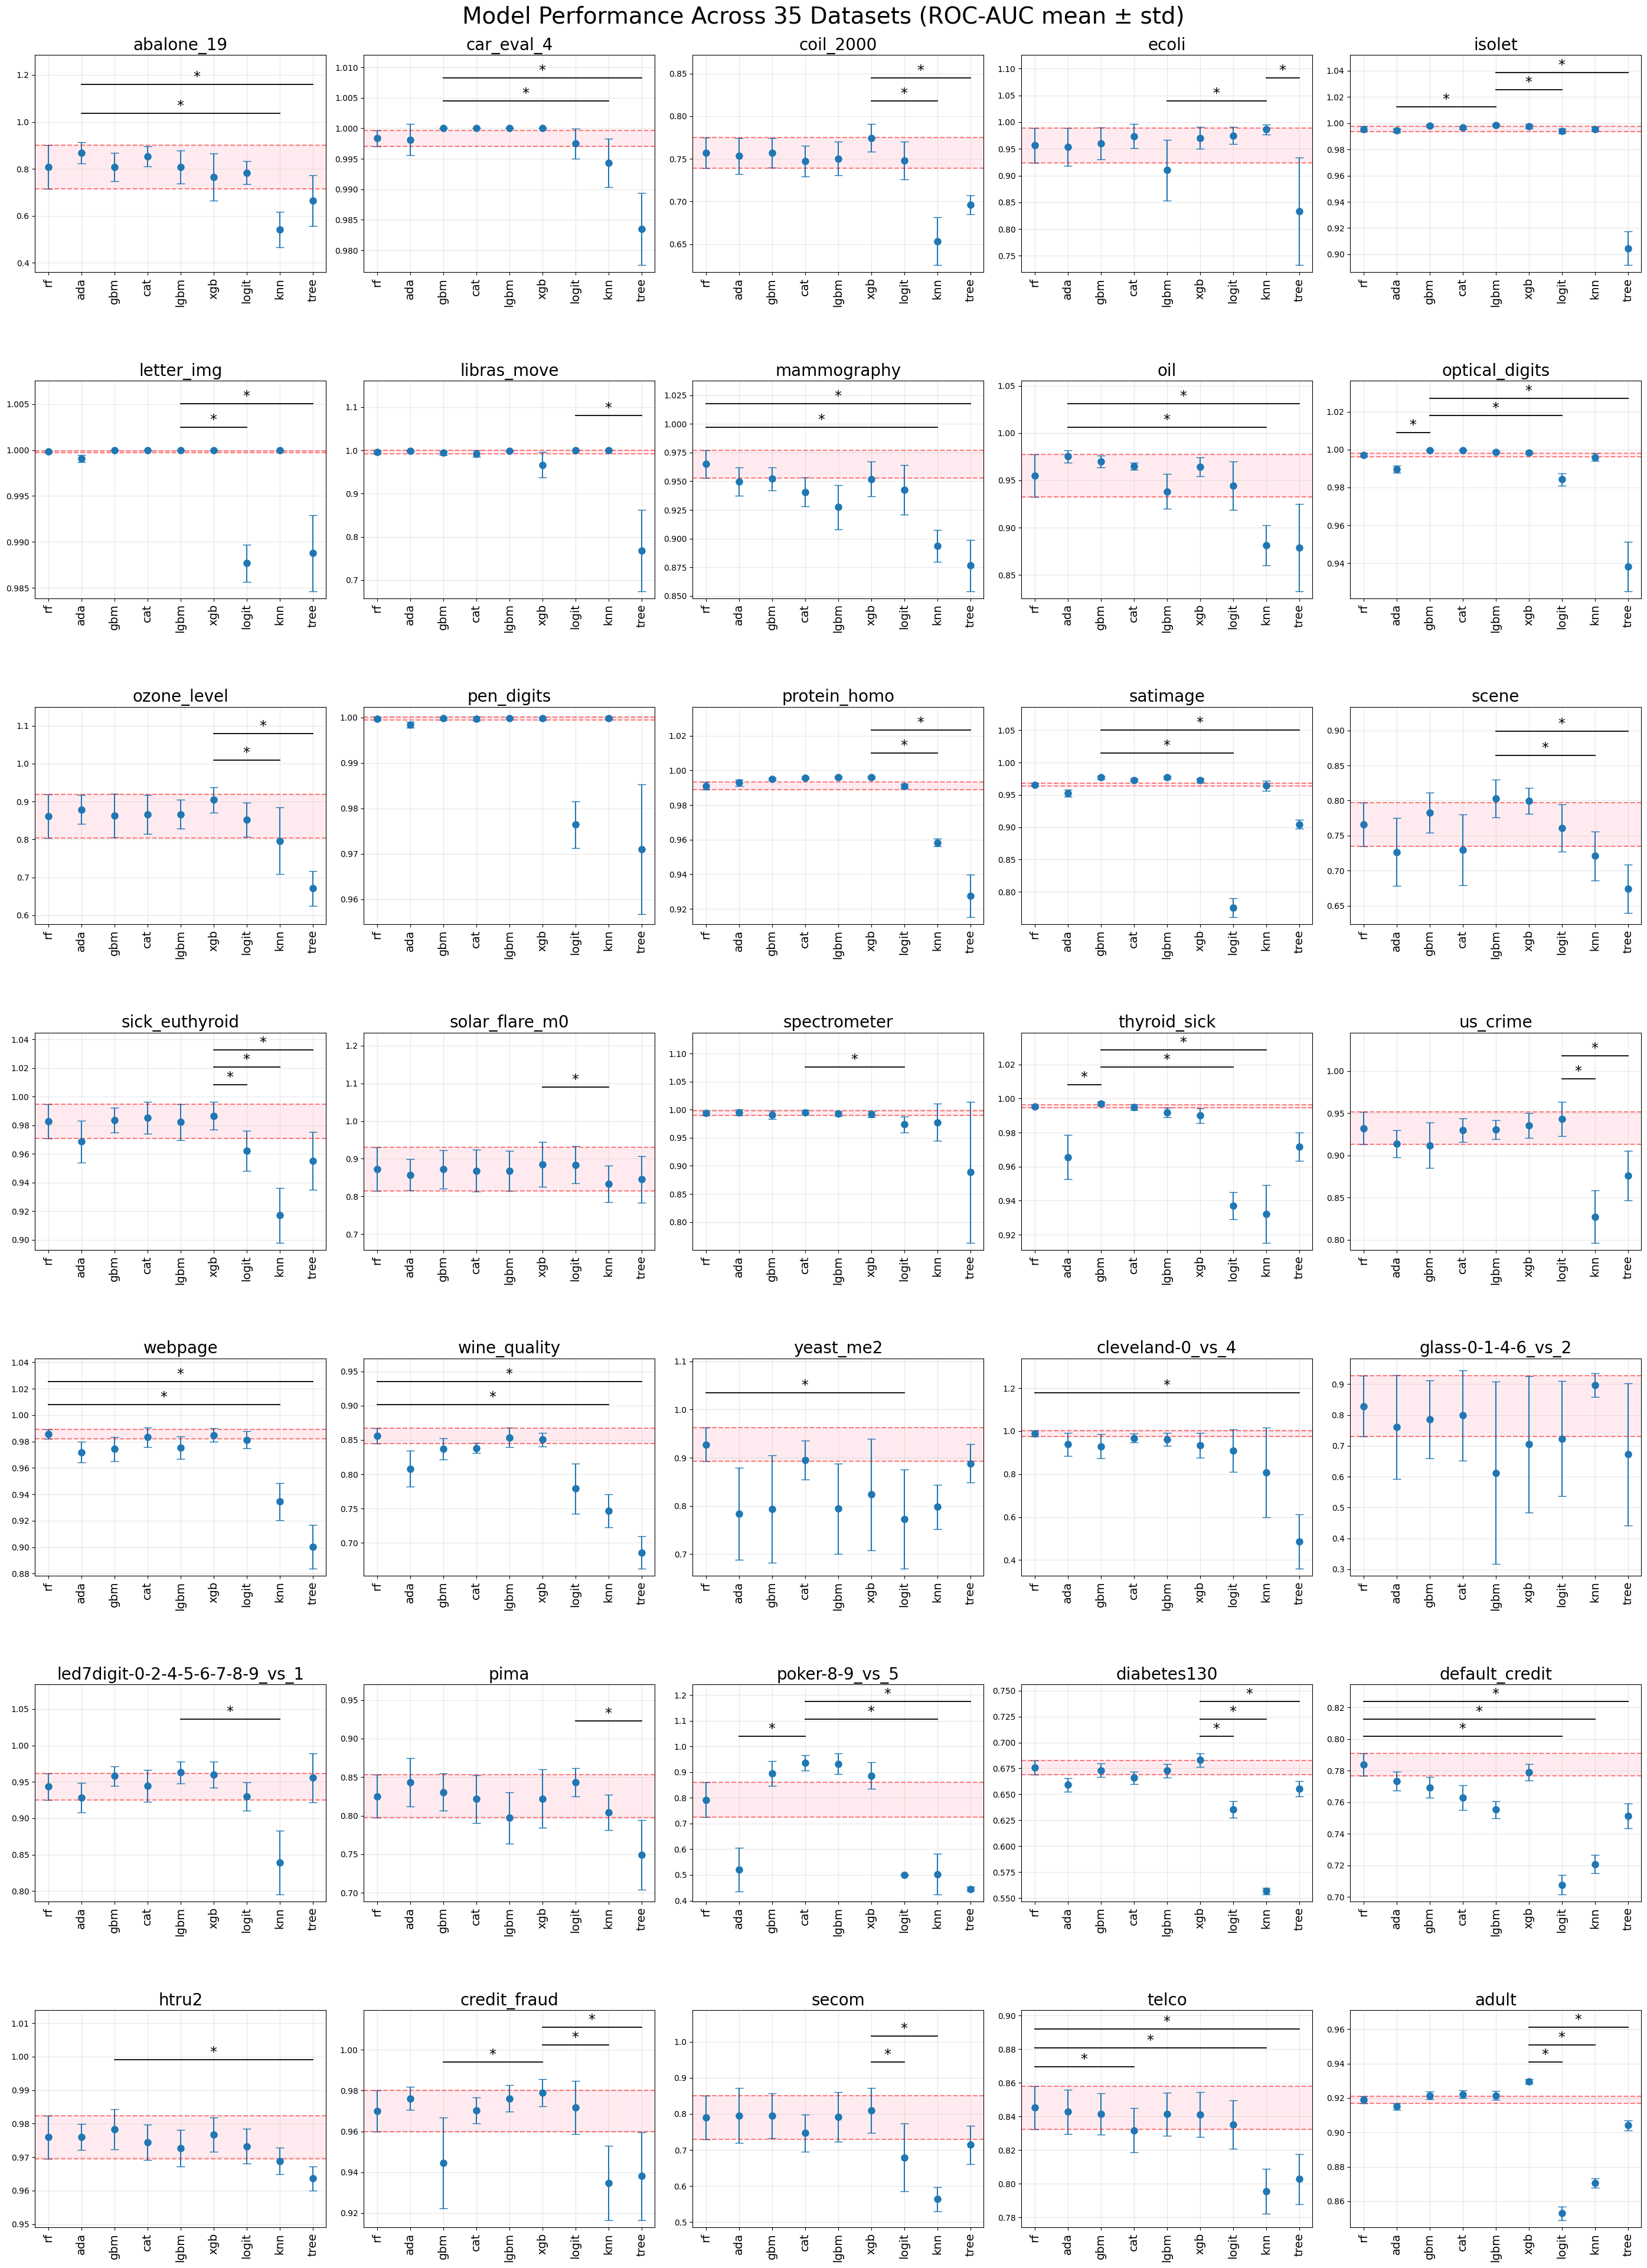

In [9]:
# 35 datasets → 7 rows × 5 cols = 35 (no empty panels)
n_rows, n_cols = 7, 5
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(28, 38))
axes = axes.ravel()

for i, data in enumerate(datasets):
    df = create_df(scores_dict, data, models)

    ax = axes[i]

    cls = df.index
    means = df.iloc[:, 0]
    stds = df.iloc[:, 1]

    upper = df.iloc[0, 0] + df.iloc[0, 1]
    lower = df.iloc[0, 0] - df.iloc[0, 1]

    best_model = None
    sig_models = []
    if data in nemenyi_dict:
        best_model = means.idxmax()
        posthoc = nemenyi_dict[data]
        sig_models = [
            m for m in models
            if m != best_model and posthoc.loc[best_model, m] < 0.05
        ]

    ax.errorbar(x=cls, y=means, yerr=stds,
                fmt='o', capsize=5, markersize=8)

    ax.set_title(data, fontsize=20)
    ylims = compute_ylim(means, stds, upper, lower)
    if sig_models:
        y0, y1 = ylims
        ylims = (y0, y1 + (y1 - y0) * 0.4)
    ax.set_ylim(ylims)
    ax.tick_params(axis='x', rotation=90, labelsize=14)
    ax.grid(True, alpha=0.3)

    ax.axhline(y=upper, color='r', linestyle='--', alpha=0.5)
    ax.axhline(y=lower, color='r', linestyle='--', alpha=0.5)
    ax.axhspan(ymin=lower, ymax=upper, facecolor='pink', alpha=0.3)

    if sig_models:
        data_max = (means + stds).max()
        add_significance_bars(ax, models, data_max, best_model, sig_models)

# Hide any unused subplots (none with 35 datasets and 35 panels, but keep for safety)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.subplots_adjust(hspace=0.5)
plt.suptitle(f'Model Performance Across {len(datasets)} Datasets (ROC-AUC mean ± std)',
             fontsize=28, y=1.01)
plt.savefig('../../mlid-book/resources/ch1/model-performance-comparison.png',
            dpi=300, bbox_inches='tight')
plt.show()

## Chapter 2, ranking vs scoring metrics

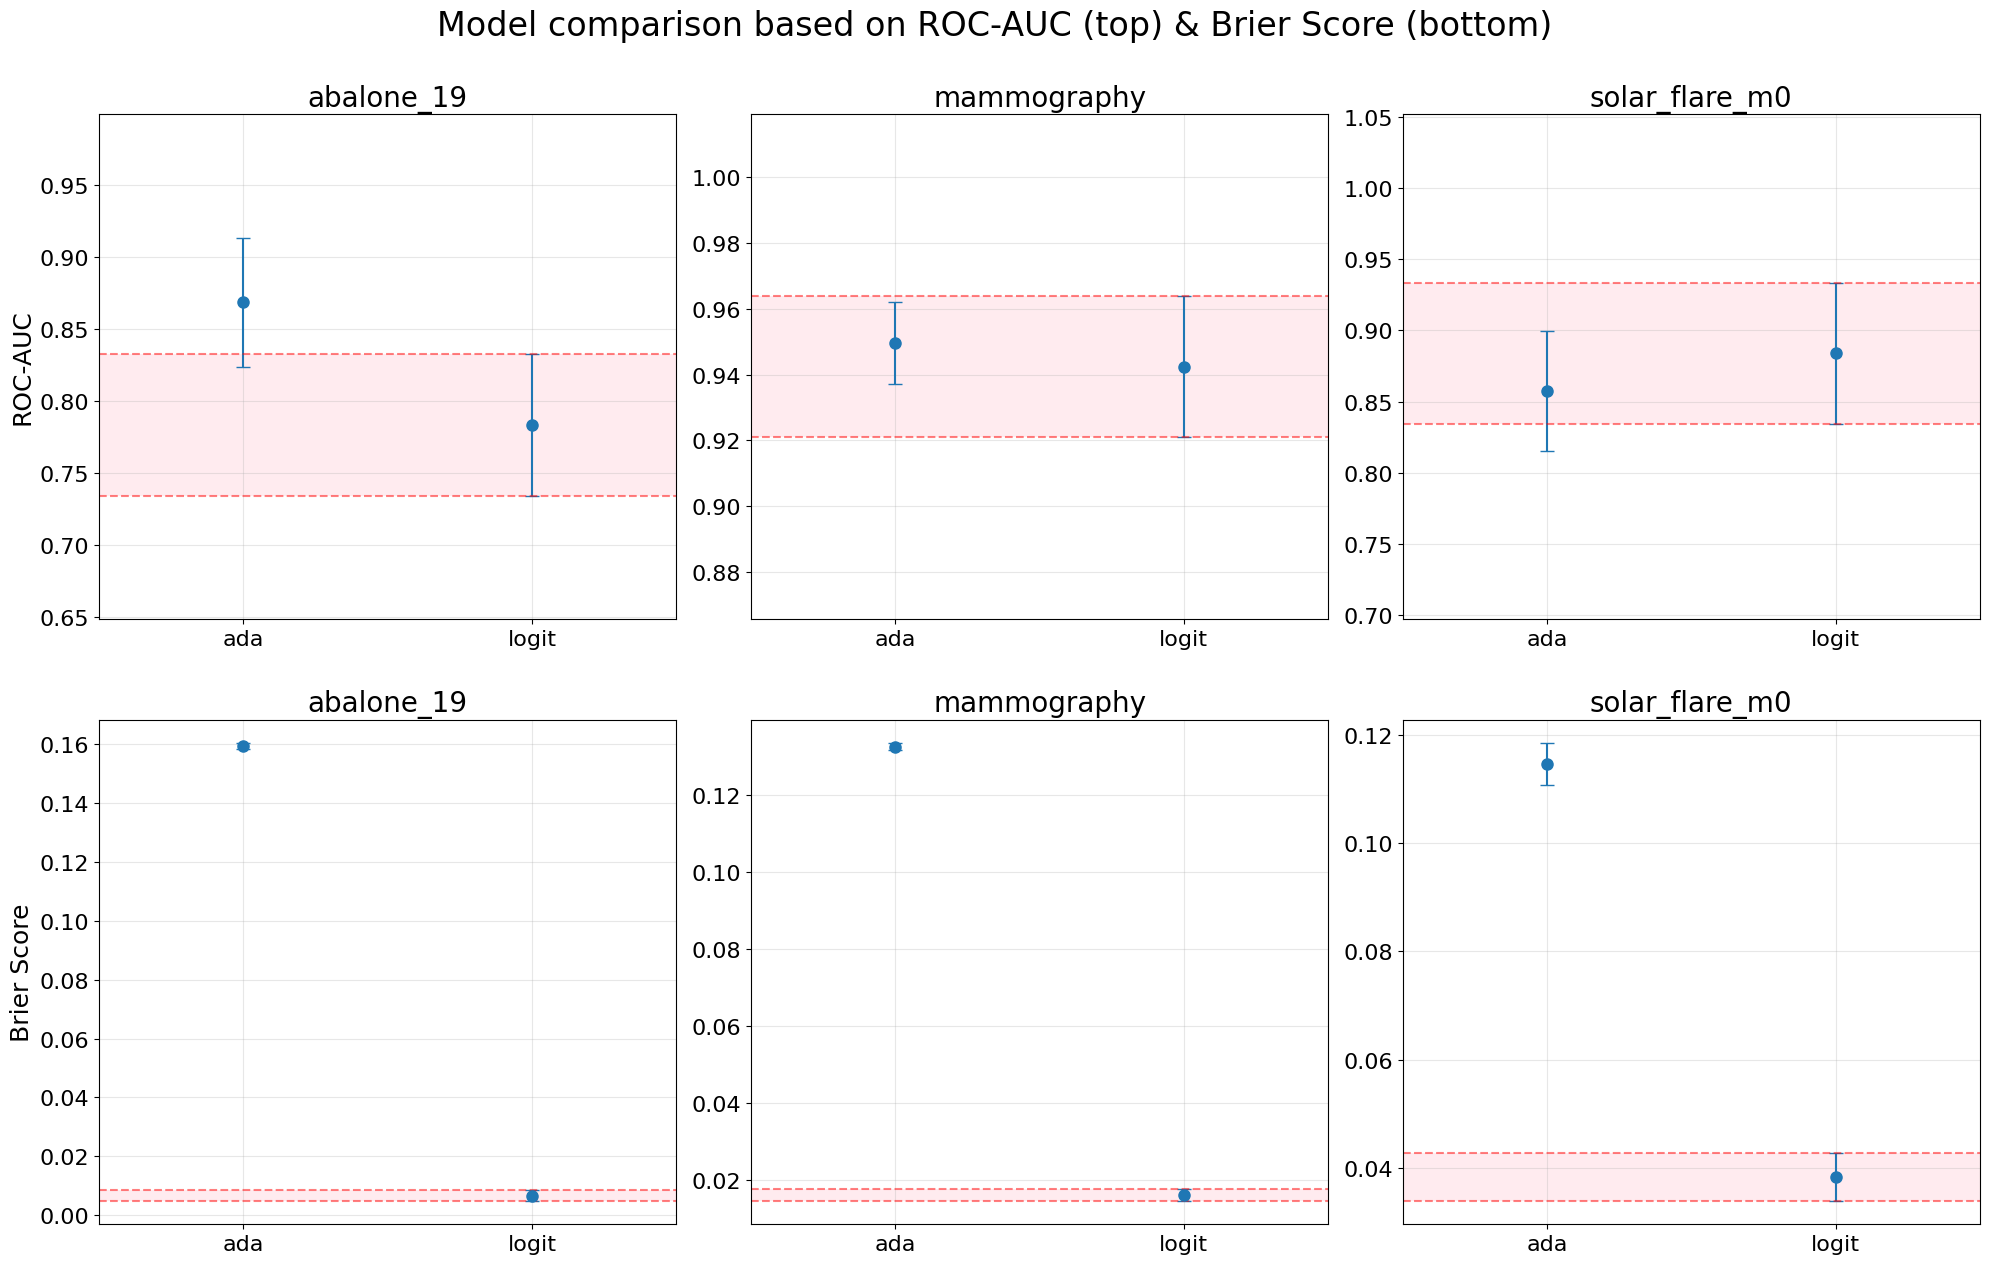

In [10]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 12))

datasets = ["abalone_19", "mammography", "solar_flare_m0"]
models = ["ada", "logit"]

# Row 0: ROC-AUC, Row 1: Brier Score
for row, (metric_name, col_mean, col_std) in enumerate([
    ("ROC-AUC", 0, 1),
    ("Brier Score", 14, 15)
]):
    for col, data in enumerate(datasets):
        df = create_df(scores_dict, data, models)
        ax = axes[row, col]

        cls = df.index
        means = df.iloc[:, col_mean]
        stds  = df.iloc[:, col_std]

        # Find logit row for the highlight band
        logit_idx = cls.get_loc("logit")
        upper = means.iloc[logit_idx] + stds.iloc[logit_idx]
        lower = means.iloc[logit_idx] - stds.iloc[logit_idx]

        # Error bar plot
        ax.errorbar(x=cls, y=means, yerr=stds,
                    fmt='o', capsize=5, markersize=8)

        # Highlight logit error bar band
        ax.axhline(y=upper, color='r', linestyle='--', alpha=0.5)
        ax.axhline(y=lower, color='r', linestyle='--', alpha=0.5)
        ax.axhspan(ymin=lower, ymax=upper, facecolor='pink', alpha=0.3)

        # Labels and formatting
        ax.set_title(f"{data}", fontsize=20)
        if col == 0:
            ax.set_ylabel(metric_name, fontsize=18)

        ylims = compute_ylim(means, stds, upper, lower)
        ax.set_ylim(ylims)
        ax.tick_params(axis='y', labelsize=16)
        ax.tick_params(axis='x', labelsize=16)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(-0.5, len(cls) - 0.5)


plt.tight_layout()
plt.subplots_adjust(hspace=0.2)
plt.suptitle('Model comparison based on ROC-AUC (top) & Brier Score (bottom)', fontsize=24, y=1.05)
plt.savefig('../../mlid-book/resources/ch2/ch2-fig2.png', dpi=300, bbox_inches='tight')
plt.show()

## Chapter 2, ROC curves

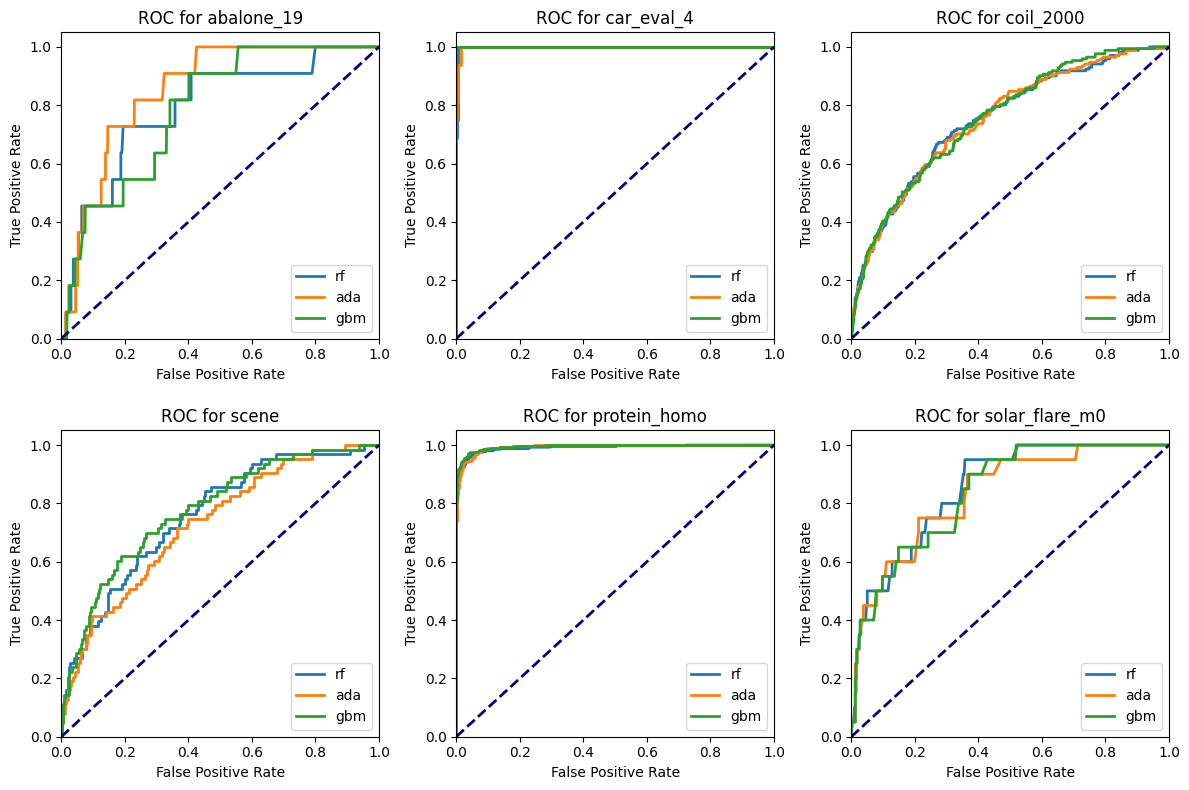

In [11]:
# Create figure with 34 subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 8))
axes = axes.ravel()  # Flatten for easy iteration

datasets = [
    "abalone_19",
    "car_eval_4",
    "coil_2000",
    "scene",
    "protein_homo",
    "solar_flare_m0",
]

models = ["rf", "ada", "gbm"]

# Loop through each DataFrame
for i, data in enumerate(datasets):
    ax = axes[i]

    # load data
    X_train, X_test, y_train, y_test = load_dataset(data)
    
    # For each model type
    for estimator in models:
        
        # load model
        search = joblib.load(f"../models/ensembles/{data}_{estimator}.pkl")

        # obtain probability
        prob = search.predict_proba(X_test)[:, 1]
        
        # Plot ROC curve
        fpr, tpr, _ =  roc_curve(y_test, prob)
        ax.plot(fpr, tpr, lw=2, label=f'{estimator}')
    
    # Format the plot
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC for {data}')
    ax.legend(loc="lower right")

# Hide empty subplots if any
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.subplots_adjust(hspace=0.3)
plt.savefig('../../mlid-book/resources/ch2/ch2-fig12.png', dpi=300, bbox_inches='tight')
plt.show()

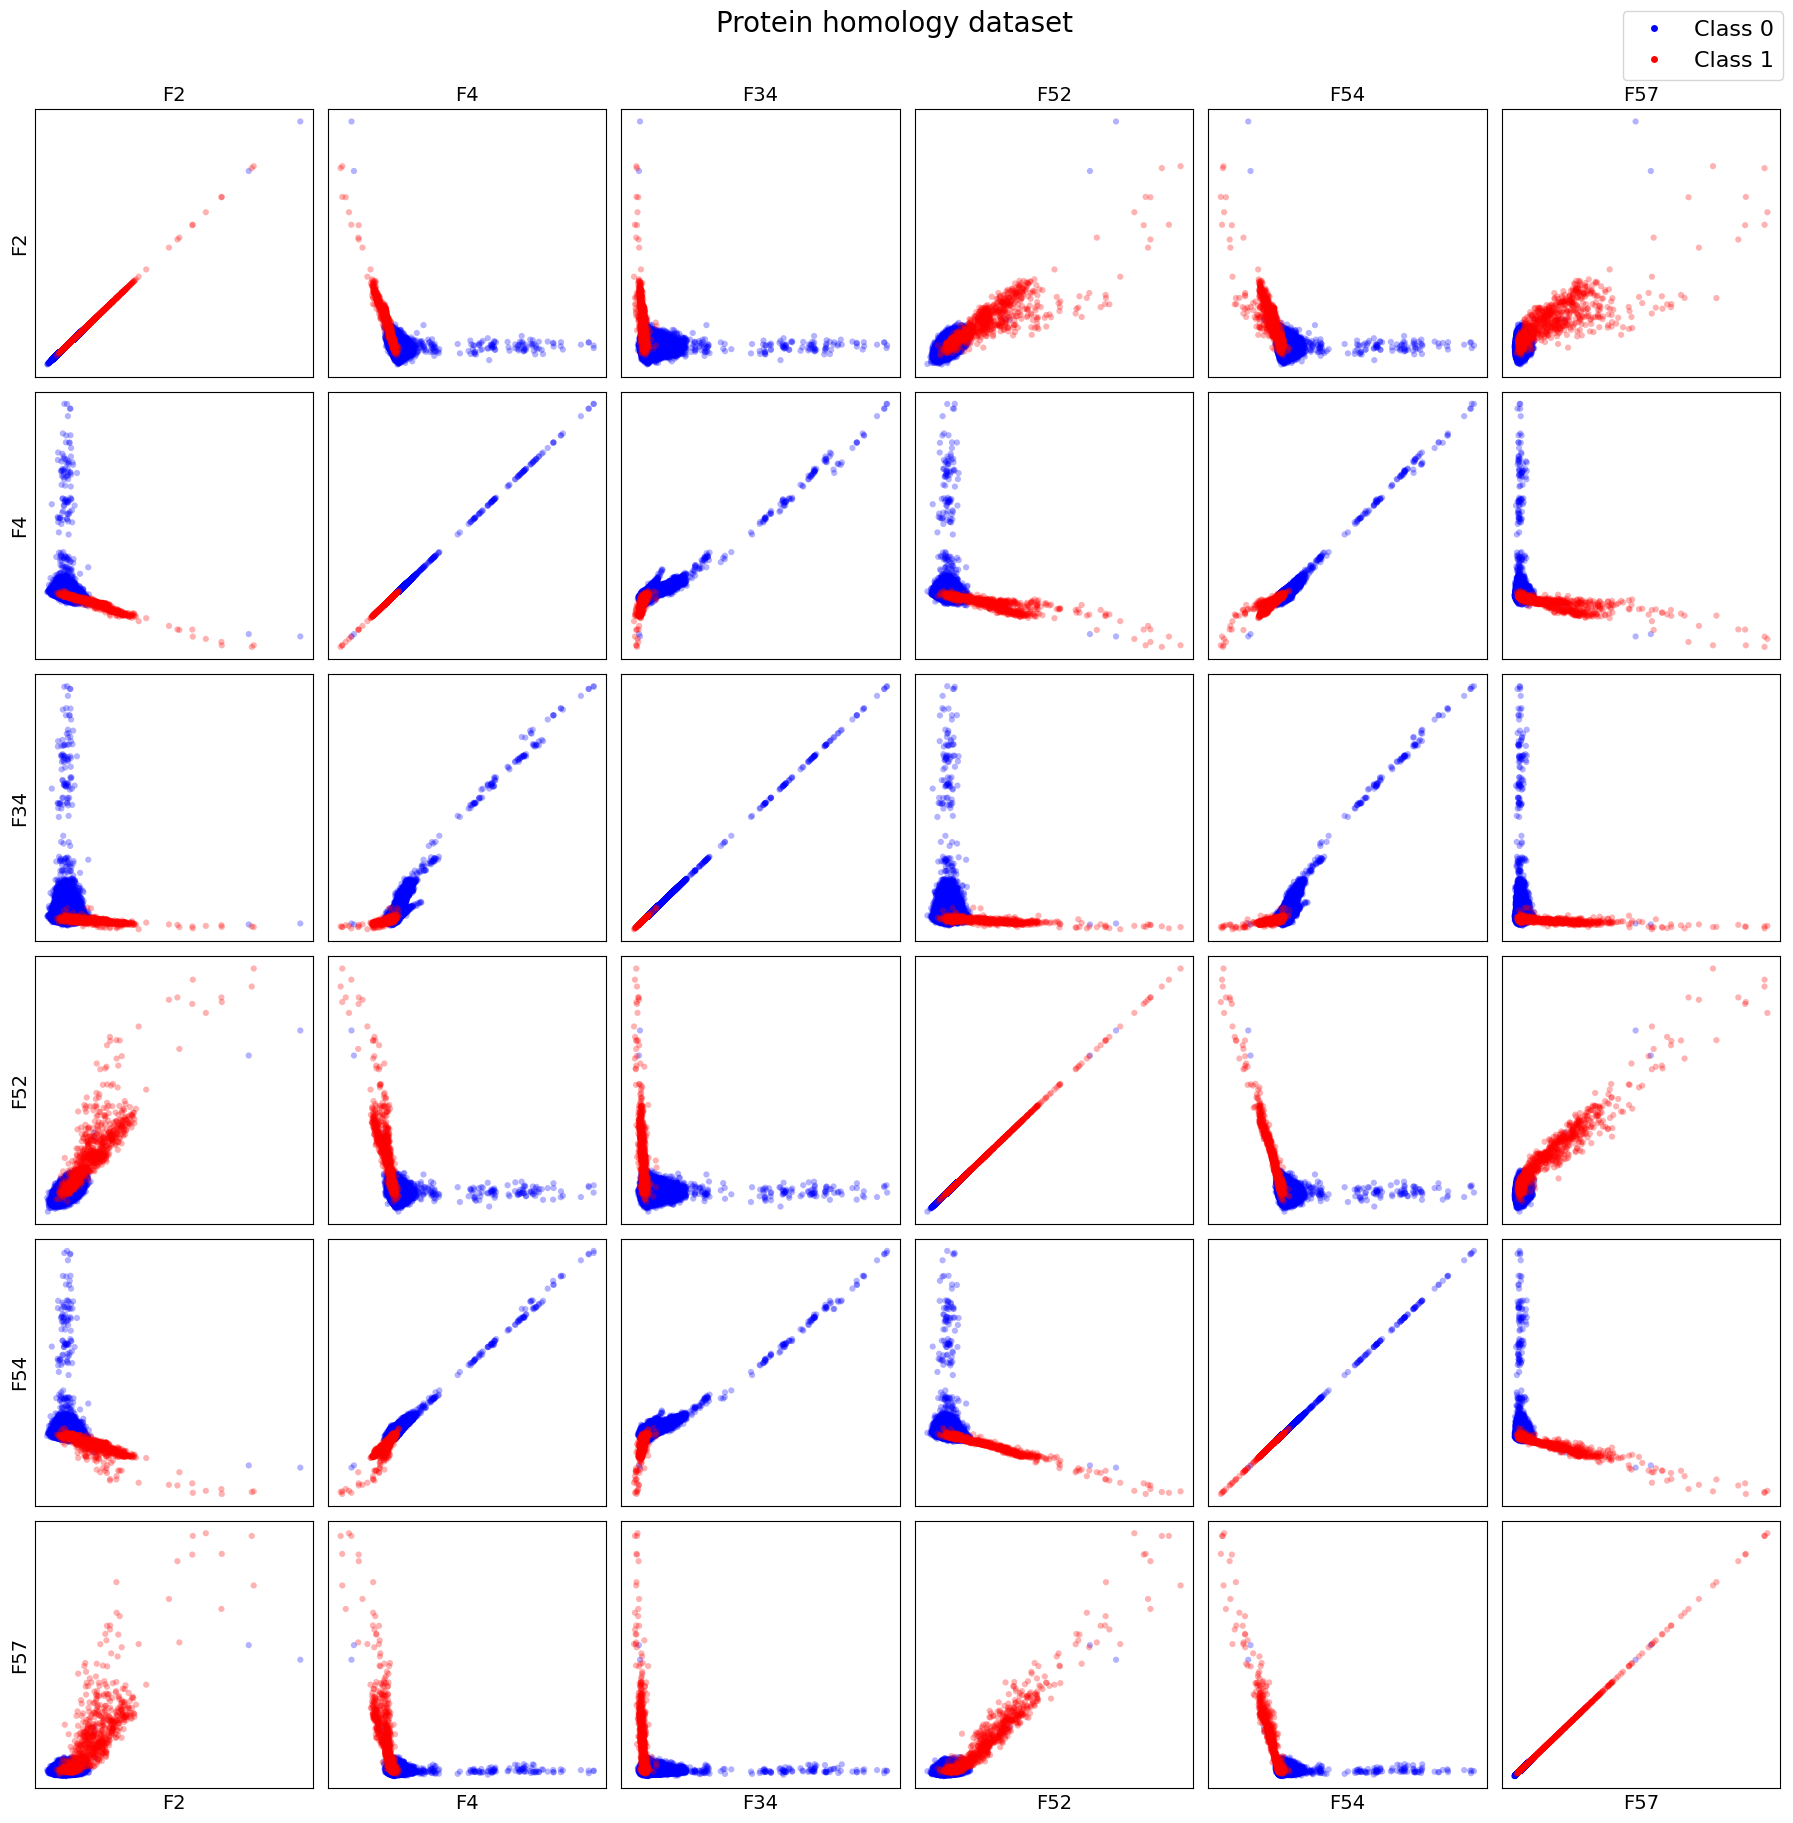

In [12]:
from sklearn.metrics import roc_auc_score

dataset = "protein_homo"
threshold = 0.9

X_train, X_test, y_train, y_test = load_dataset(dataset)

# find good features
good_features = []
for j in range(X_train.shape[1]):
    col = X_train.iloc[:, j] if hasattr(X_train, "iloc") else X_train[:, j]
    auc = roc_auc_score(y_train, col)
    auc = max(auc, 1 - auc)
    if auc >= threshold:
        feat_name = X_train.columns[j] if hasattr(X_train, "columns") else j
        good_features.append((feat_name, round(auc, 3)))


# Scatter plots
feat_names = [f[0] for f in good_features]
n = len(feat_names)
fig, axes = plt.subplots(n, n, figsize=(n * 3, n * 3))
if n == 1:
    axes = np.array([[axes]])
for i, fi in enumerate(feat_names):
    for j, fj in enumerate(feat_names):
        ax = axes[i, j]
        for label, color in zip([0, 1], ["blue", "red"]):
            mask = y_train == label
            xi = X_train.iloc[mask, X_train.columns.get_loc(fi)] if hasattr(X_train, "iloc") else X_train[mask, fi]
            xj = X_train.iloc[mask, X_train.columns.get_loc(fj)] if hasattr(X_train, "iloc") else X_train[mask, fj]
            ax.scatter(xj, xi, c=color, edgecolor="none", alpha=0.3, s=20)
        if i == n - 1:
            ax.set_xlabel(f"F{fj}", fontsize=14)
        if j == 0:
            ax.set_ylabel(f"F{fi}", fontsize=14)
        if i == 0:
            ax.set_title(f"F{fj}", fontsize=14)
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=c, label=f"Class {l}")
           for l, c in zip([0, 1], ["blue", "red"])]
fig.legend(handles=handles, loc="upper right", fontsize=16)
plt.suptitle("Protein homology dataset", y=1.01, fontsize=20)
plt.tight_layout()
plt.savefig('../../mlid-book/resources/ch2/ch2-fig13.png', dpi=300, bbox_inches='tight')
plt.show()

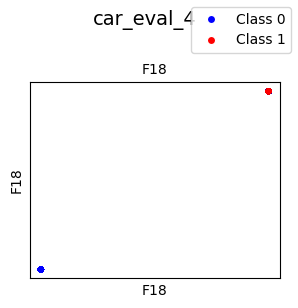

In [13]:
dataset = "car_eval_4"
threshold = 0.8

X_train, X_test, y_train, y_test = load_dataset(dataset)

# find good features
good_features = []
for j in range(X_train.shape[1]):
    col = X_train.iloc[:, j] if hasattr(X_train, "iloc") else X_train[:, j]
    auc = roc_auc_score(y_train, col)
    auc = max(auc, 1 - auc)
    if auc >= threshold:
        feat_name = X_train.columns[j] if hasattr(X_train, "columns") else j
        good_features.append((feat_name, round(auc, 3)))


# Scatter plots
feat_names = [f[0] for f in good_features]
n = len(feat_names)
fig, axes = plt.subplots(n, n, figsize=(n * 3, n * 3))
if n == 1:
    axes = np.array([[axes]])
for i, fi in enumerate(feat_names):
    for j, fj in enumerate(feat_names):
        ax = axes[i, j]
        for label, color in zip([0, 1], ["blue", "red"]):
            mask = y_train == label
            xi = X_train.iloc[mask, X_train.columns.get_loc(fi)] if hasattr(X_train, "iloc") else X_train[mask, fi]
            xj = X_train.iloc[mask, X_train.columns.get_loc(fj)] if hasattr(X_train, "iloc") else X_train[mask, fj]
            ax.scatter(xj, xi, c=color, edgecolor="none", alpha=0.3, s=20)
        if i == n - 1:
            ax.set_xlabel(f"F{fj}", fontsize=10)
        if j == 0:
            ax.set_ylabel(f"F{fi}", fontsize=10)
        if i == 0:
            ax.set_title(f"F{fj}", fontsize=10)
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=c, label=f"Class {l}")
           for l, c in zip([0, 1], ["blue", "red"])]
fig.legend(handles=handles, loc="upper right", fontsize=10)
plt.suptitle(f"{dataset}", y=1.01, fontsize=14)
plt.tight_layout()
# plt.savefig('../../mlid-book/resources/ch2/ch2-fig12.png', dpi=300, bbox_inches='tight')
plt.show()

## Chapter 2, PR vs ROC curves

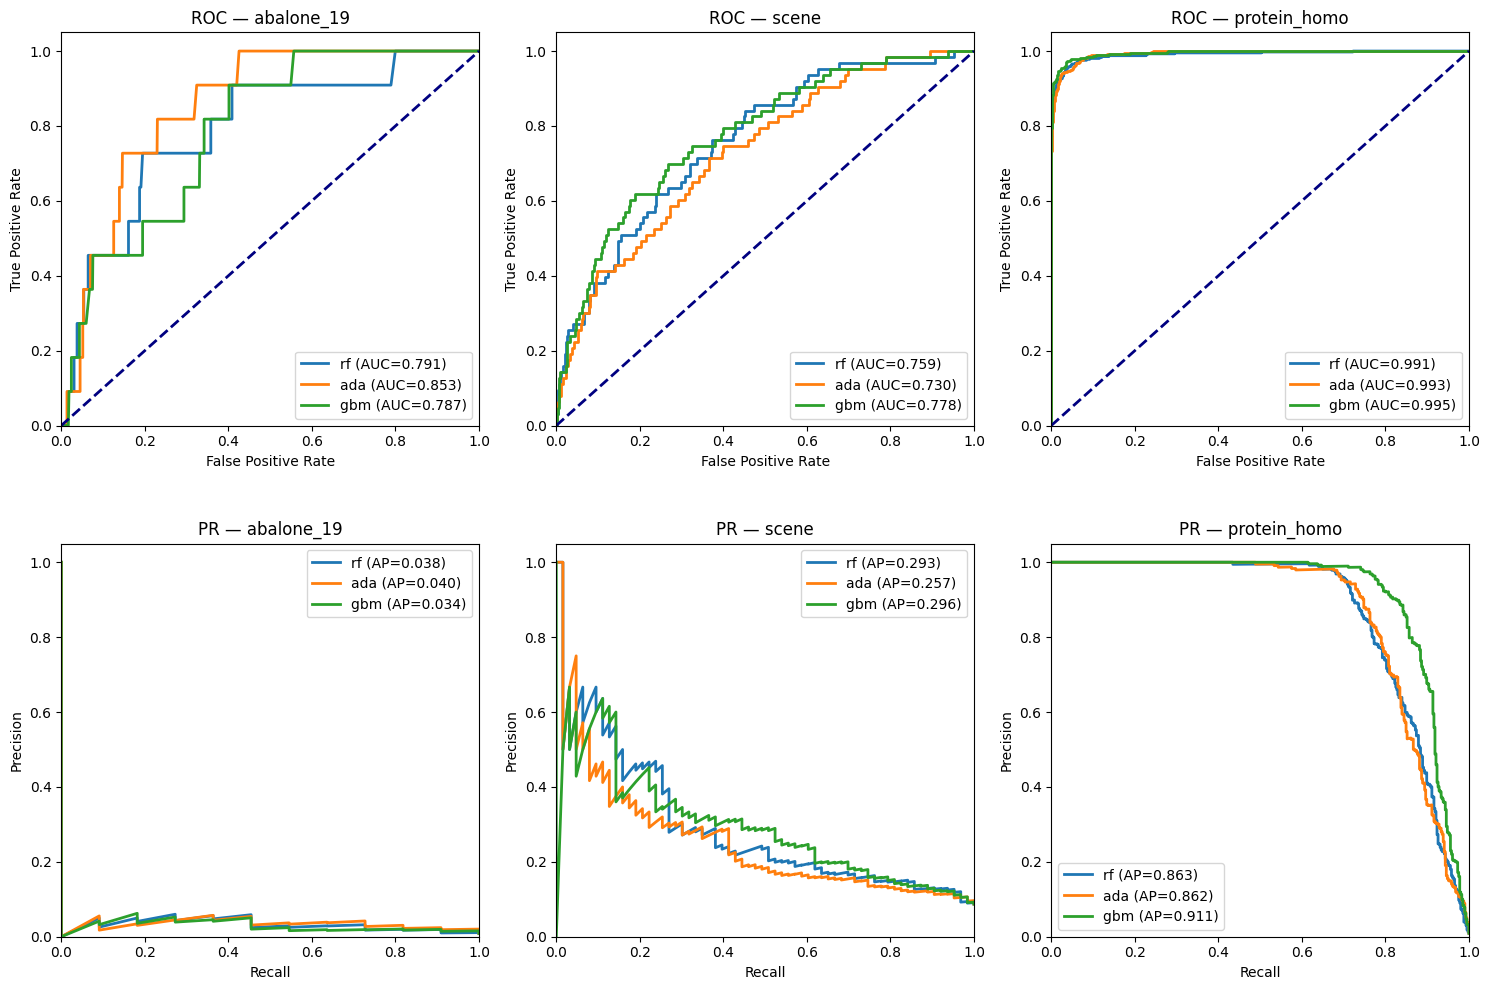

In [14]:
from sklearn.metrics import average_precision_score

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))

datasets = ["abalone_19", "scene", "protein_homo"]
models   = ["rf", "ada", "gbm"]

for col, data in enumerate(datasets):
    X_train, X_test, y_train, y_test = load_dataset(data)

    for estimator in models:
        search = joblib.load(f"../models/ensembles/{data}_{estimator}.pkl")
        prob   = search.predict_proba(X_test)[:, 1]
        
        roc_auc = roc_auc_score(y_test, prob)
        pr_auc  = average_precision_score(y_test, prob)

        # ROC — top row
        fpr, tpr, _ = roc_curve(y_test, prob)
        axes[0, col].plot(fpr, tpr, lw=2, label=f"{estimator} (AUC={roc_auc:.3f})")

        # PR — bottom row
        prec, rec, _ = precision_recall_curve(y_test, prob)
        axes[1, col].plot(rec, prec, lw=2, label=f"{estimator} (AP={pr_auc:.3f})")
        
    # ROC formatting
    axes[0, col].plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
    axes[0, col].set(xlim=[0, 1], ylim=[0, 1.05],
                     xlabel="False Positive Rate", ylabel="True Positive Rate",
                     title=f"ROC — {data}")
    axes[0, col].legend(loc="lower right")

    # PR formatting
    axes[1, col].set(xlim=[0, 1], ylim=[0, 1.05],
                     xlabel="Recall", ylabel="Precision",
                     title=f"PR — {data}")
    axes[1, col].legend(loc="upper right")

axes[1, 2].legend(loc="lower left")
plt.tight_layout()
plt.subplots_adjust(hspace=0.3)
plt.savefig("../../mlid-book/resources/ch2/ch2-fig16.png", dpi=300, bbox_inches="tight")
plt.show()

## Chapter 4, Class weights

Pick 5 datasets for which the ROC-AUC is not super close to 1.

For each dataset, select all models trained on the original distribution, and the same models now trained with the strongest class weights.

For each dataset plot:

- ROC-AUC and Brier Score
- Balanced accuracy and optimal threshold

In [15]:
with open('../models/csl/results.pkl', 'rb') as f:
    csl_scores = pickle.load(f)

with open('../models/csl/results_folds.pkl', 'rb') as f:
    csl_folds = pickle.load(f)

# merge the class-weight (CSL) results with the existing ensemble + basic results
ch4_scores_dict = {
    dataset: {**scores_dict[dataset], **csl_scores[dataset]}
    for dataset in csl_scores
}

ch4_folds_dict = {
    dataset: {**folds_dict[dataset], **csl_folds[dataset]}
    for dataset in csl_folds
}

In [16]:
base_models = ["rf", "ada", "gbm", "cat", "lgbm", "xgb"]

# 5 datasets for which the ROC-AUC (best base ensemble) is not super close to 1
roc_by_dataset = {}
for data in csl_scores:
    df = create_df(scores_dict, data, base_models)
    roc_by_dataset[data] = df["roc"].max()

chapter4_datasets = sorted(roc_by_dataset, key=roc_by_dataset.get)[:5]
chapter4_datasets = [d if d != "scene" else "bank-marketing" for d in chapter4_datasets]
chapter4_datasets

['diabetes130', 'coil_2000', 'default_credit', 'bank-marketing', 'secom']

In [17]:
def strongest_cw_models(csl_scores, dataset, base_models):
    """For each base model, find its variant with the largest sample-weight
    multiplier (the "strongest" class weight) for the given dataset."""
    keys = list(csl_scores[dataset].keys())
    best = {}
    for k in keys:
        base, sw = k.rsplit("_sw", 1)
        sw = int(sw)
        if base not in best or sw > best[base][1]:
            best[base] = (k, sw)
    return [best[b][0] for b in base_models]


# for each dataset: original-distribution models + their strongest class-weight variant
chapter4_models = {
    data: base_models + strongest_cw_models(csl_scores, data, base_models)
    for data in chapter4_datasets
}
chapter4_models

{'diabetes130': ['rf',
  'ada',
  'gbm',
  'cat',
  'lgbm',
  'xgb',
  'rf_sw8',
  'ada_sw8',
  'gbm_sw8',
  'cat_sw8',
  'lgbm_sw8',
  'xgb_sw8'],
 'coil_2000': ['rf',
  'ada',
  'gbm',
  'cat',
  'lgbm',
  'xgb',
  'rf_sw16',
  'ada_sw16',
  'gbm_sw16',
  'cat_sw16',
  'lgbm_sw16',
  'xgb_sw16'],
 'default_credit': ['rf',
  'ada',
  'gbm',
  'cat',
  'lgbm',
  'xgb',
  'rf_sw3',
  'ada_sw3',
  'gbm_sw3',
  'cat_sw3',
  'lgbm_sw3',
  'xgb_sw3'],
 'bank-marketing': ['rf',
  'ada',
  'gbm',
  'cat',
  'lgbm',
  'xgb',
  'rf_sw8',
  'ada_sw8',
  'gbm_sw8',
  'cat_sw8',
  'lgbm_sw8',
  'xgb_sw8'],
 'secom': ['rf',
  'ada',
  'gbm',
  'cat',
  'lgbm',
  'xgb',
  'rf_sw13',
  'ada_sw13',
  'gbm_sw13',
  'cat_sw13',
  'lgbm_sw13',
  'xgb_sw13']}

In [18]:
# Friedman + Nemenyi tests, restricted to the original-distribution and
# strongest-class-weight models selected above, one test per dataset per metric
def friedman_nemenyi_for_metric(folds_dict, datasets, models_dict, metric):
    nemenyi = {}
    for data in datasets:
        models = models_dict[data]
        fold_df = create_fold_df(folds_dict, data, metric)[models]
        statistic, pvalue = apply_friedman_test(fold_df)
        if pvalue < 0.05:
            nemenyi[data] = apply_nemenyi_test(fold_df)
    return nemenyi


nemenyi_roc = friedman_nemenyi_for_metric(ch4_folds_dict, chapter4_datasets, chapter4_models, "roc")
nemenyi_ba = friedman_nemenyi_for_metric(ch4_folds_dict, chapter4_datasets, chapter4_models, "ba")
nemenyi_brier = friedman_nemenyi_for_metric(ch4_folds_dict, chapter4_datasets, chapter4_models, "brier")

### ROC-AUC & Brier Score

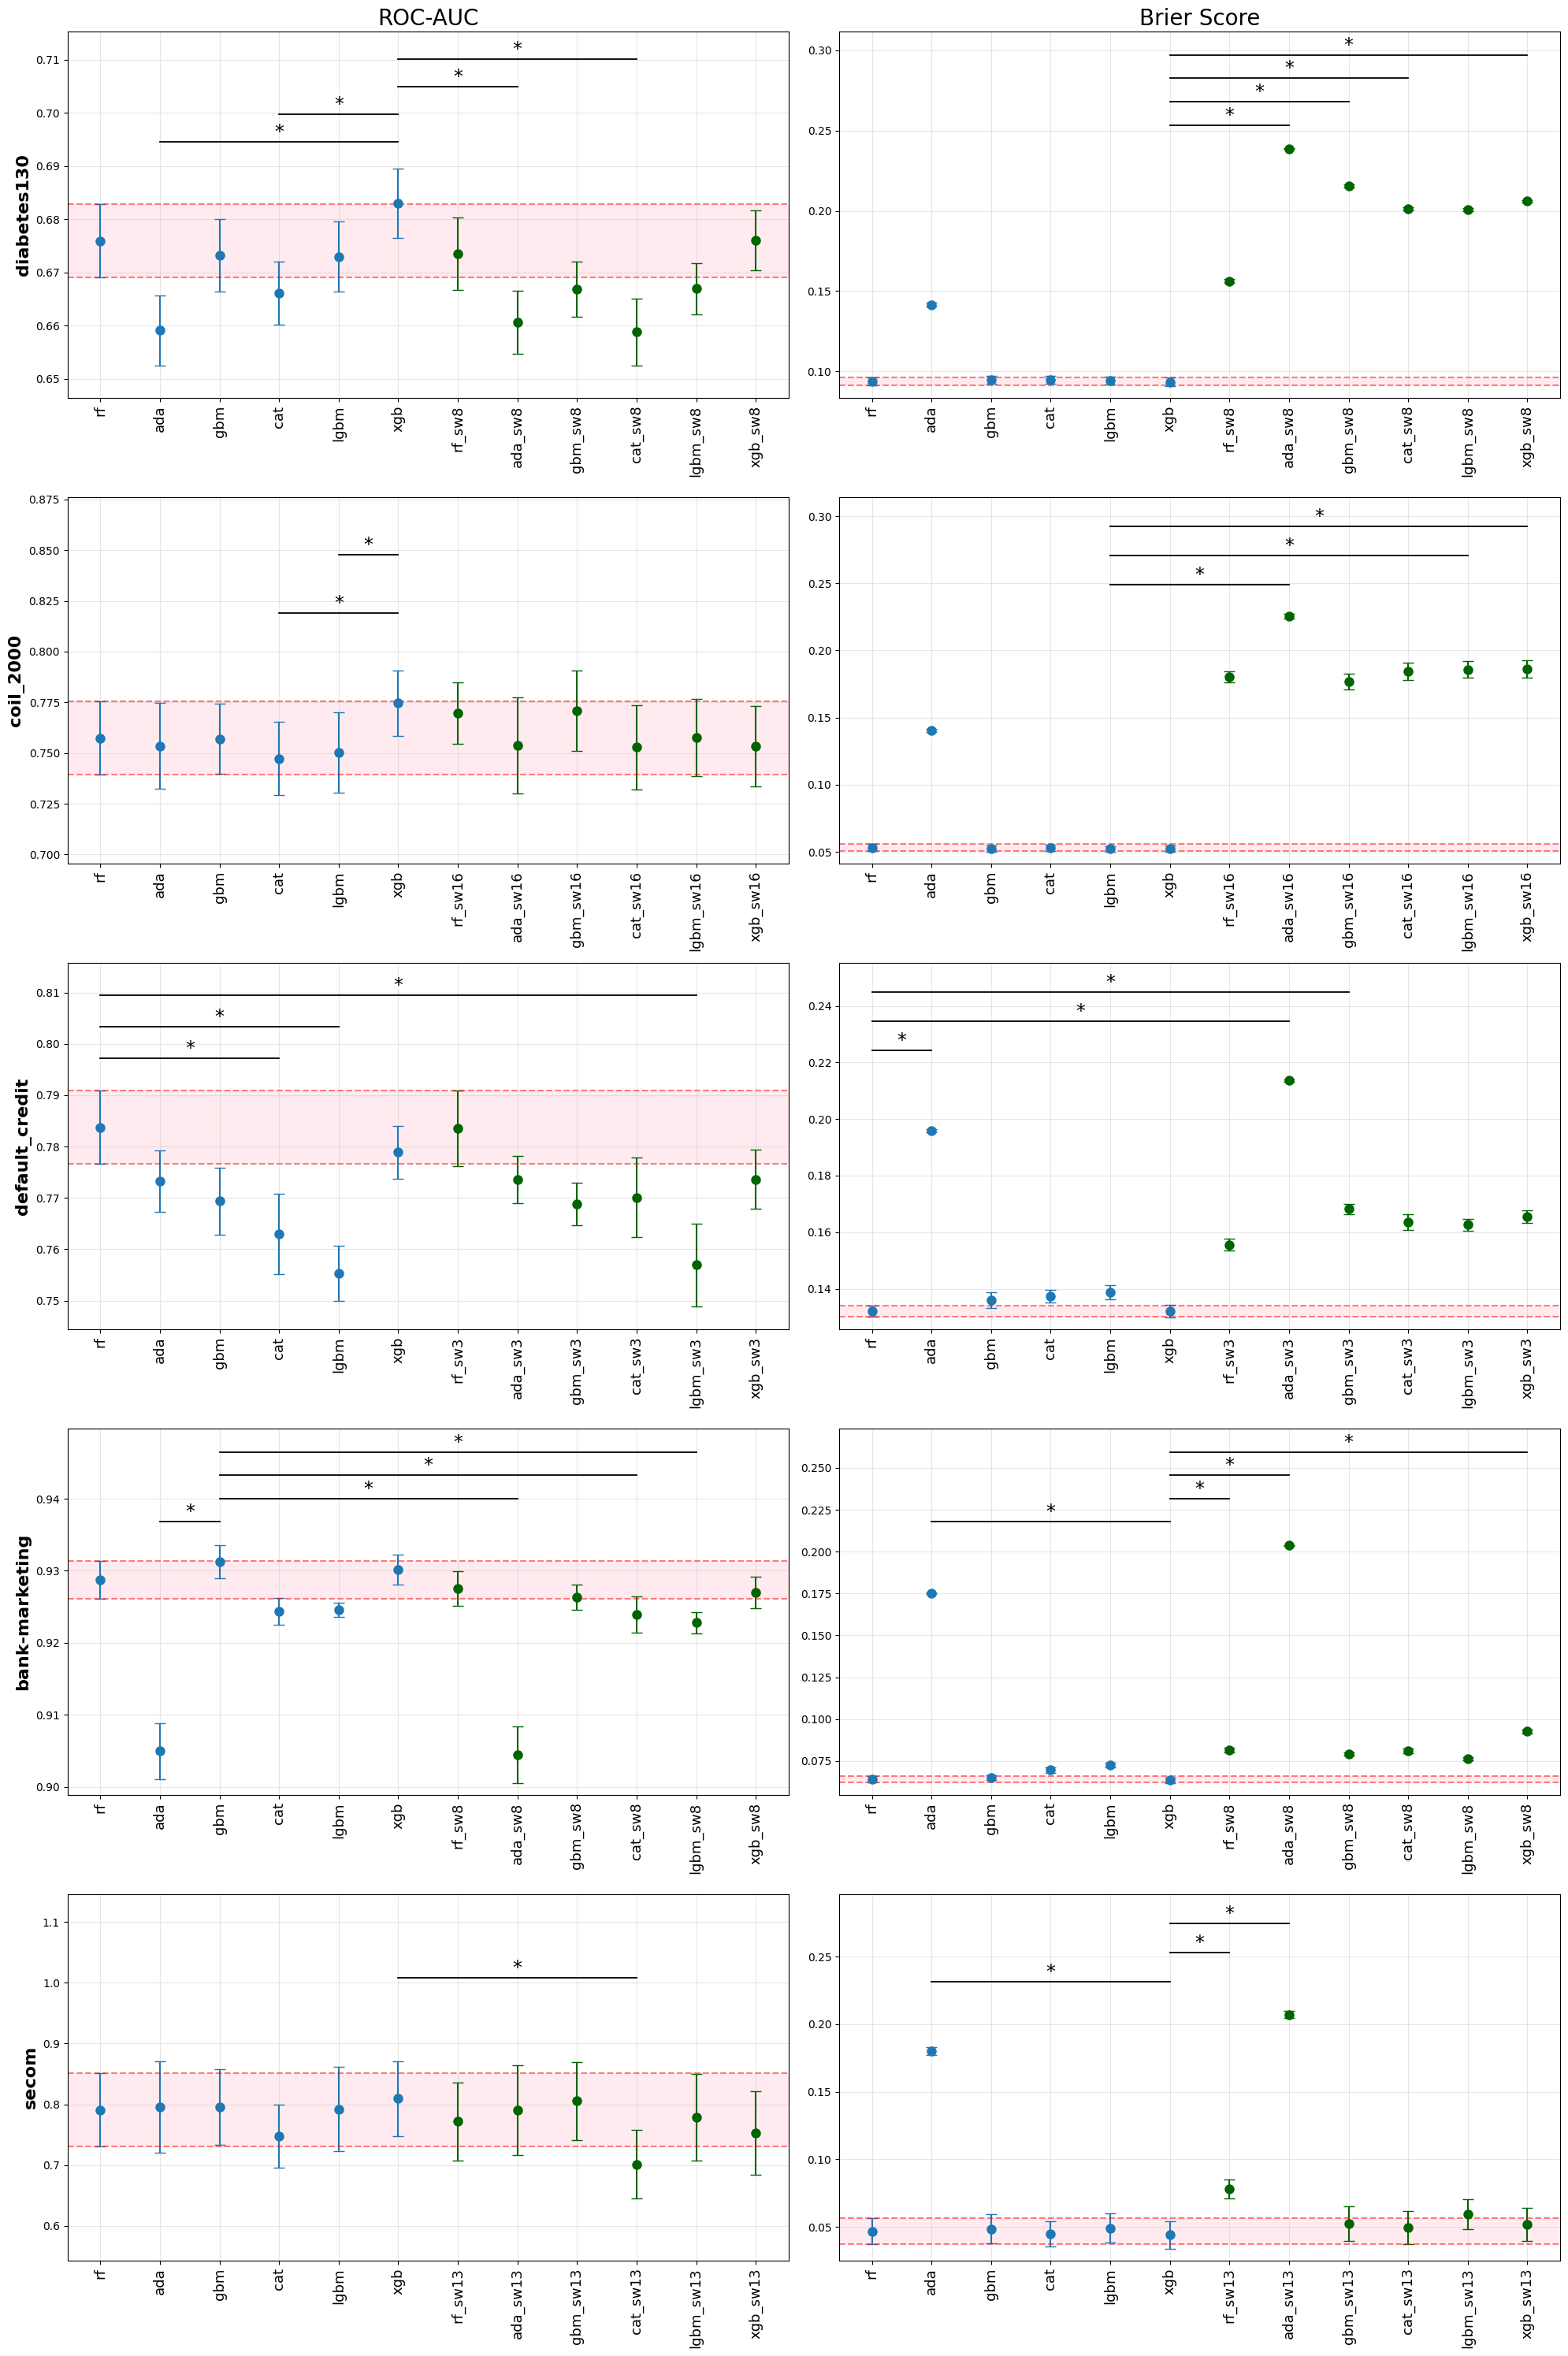

In [19]:
# One row per dataset. Column 0: ROC-AUC, column 1: Brier Score
fig, axes = plt.subplots(nrows=len(chapter4_datasets), ncols=2, figsize=(20, 6 * len(chapter4_datasets)))

metric_specs = [
    ("ROC-AUC", 0, 1, nemenyi_roc, "max"),
    ("Brier Score", 14, 15, nemenyi_brier, "min"),
]

for row, data in enumerate(chapter4_datasets):
    models = chapter4_models[data]
    df = create_df(ch4_scores_dict, data, models)

    for col, (metric_name, col_mean, col_std, nemenyi_dict_metric, direction) in enumerate(metric_specs):
        ax = axes[row, col]

        cls = df.index
        means = df.iloc[:, col_mean]
        stds = df.iloc[:, col_std]
        is_cw = np.array(["_sw" in m for m in cls])

        upper = df.iloc[0, col_mean] + df.iloc[0, col_std]
        lower = df.iloc[0, col_mean] - df.iloc[0, col_std]

        best_model = None
        sig_models = []
        if data in nemenyi_dict_metric:
            best_model = means.idxmax() if direction == "max" else means.idxmin()
            posthoc = nemenyi_dict_metric[data]
            sig_models = [
                m for m in models
                if m != best_model and posthoc.loc[best_model, m] < 0.05
            ]

        # original-distribution models in default color, class-weight models in dark green
        ax.errorbar(x=cls[~is_cw], y=means[~is_cw], yerr=stds[~is_cw],
                    fmt='o', capsize=5, markersize=8, color='tab:blue')
        ax.errorbar(x=cls[is_cw], y=means[is_cw], yerr=stds[is_cw],
                    fmt='o', capsize=5, markersize=8, color='darkgreen')

        if col == 0:
            ax.set_ylabel(data, fontsize=16, fontweight="bold")
        if row == 0:
            ax.set_title(metric_name, fontsize=20)

        ylims = compute_ylim(means, stds, upper, lower)
        if sig_models:
            y0, y1 = ylims
            ylims = (y0, y1 + (y1 - y0) * 0.4)
        ax.set_ylim(ylims)
        ax.tick_params(axis='x', rotation=90, labelsize=13)
        ax.grid(True, alpha=0.3)

        ax.axhline(y=upper, color='r', linestyle='--', alpha=0.5)
        ax.axhline(y=lower, color='r', linestyle='--', alpha=0.5)
        ax.axhspan(ymin=lower, ymax=upper, facecolor='pink', alpha=0.3)

        if sig_models:
            data_max = (means + stds).max()
            add_significance_bars(ax, models, data_max, best_model, sig_models)

plt.tight_layout()
plt.savefig('../../mlid-book/resources/ch4/ch4-fig2.png', dpi=300, bbox_inches='tight')
plt.show()

### Balanced Accuracy & Threshold

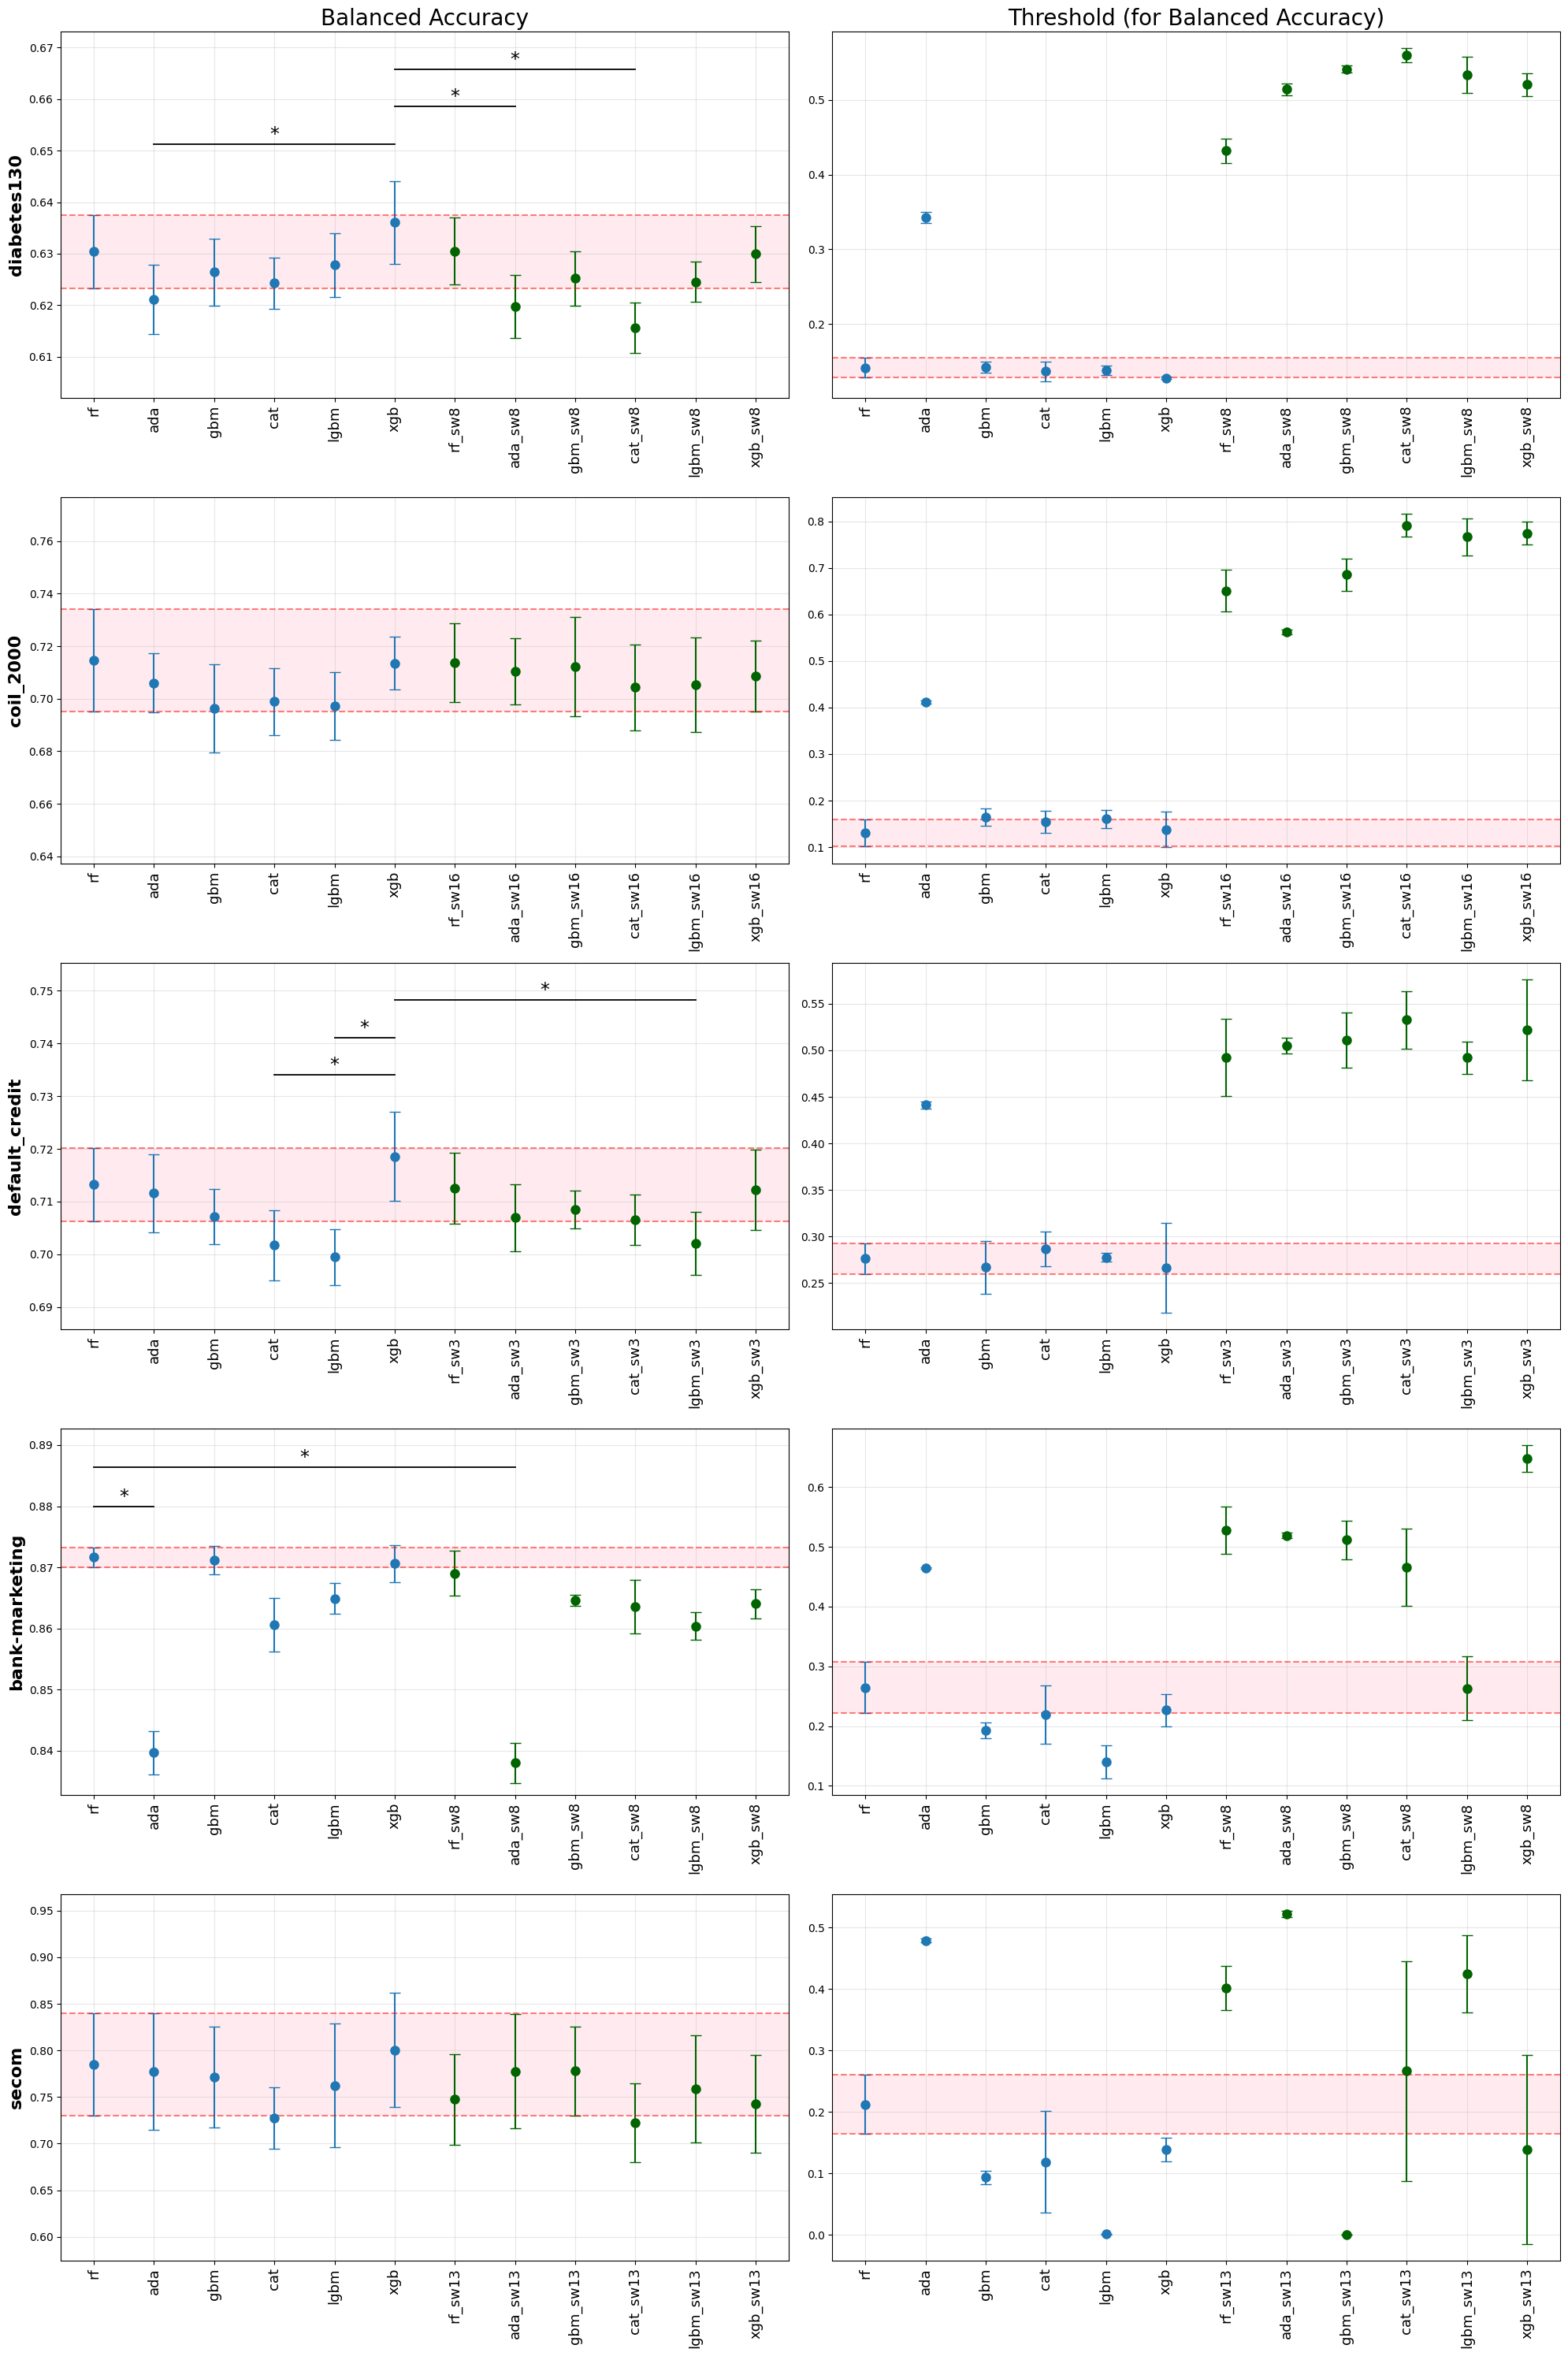

In [20]:
# One row per dataset. Column 0: Balanced Accuracy, column 1: threshold used for it.
# The threshold is an operating point, not a performance metric, so it has no
# "best" direction and is plotted without significance bars.
fig, axes = plt.subplots(nrows=len(chapter4_datasets), ncols=2, figsize=(20, 6 * len(chapter4_datasets)))

metric_specs = [
    ("Balanced Accuracy", 12, 13, nemenyi_ba),
    ("Threshold (for Balanced Accuracy)", 18, 19, None),
]

for row, data in enumerate(chapter4_datasets):
    models = chapter4_models[data]
    df = create_df(ch4_scores_dict, data, models)

    for col, (metric_name, col_mean, col_std, nemenyi_dict_metric) in enumerate(metric_specs):
        ax = axes[row, col]

        cls = df.index
        means = df.iloc[:, col_mean]
        stds = df.iloc[:, col_std]
        is_cw = np.array(["_sw" in m for m in cls])

        upper = df.iloc[0, col_mean] + df.iloc[0, col_std]
        lower = df.iloc[0, col_mean] - df.iloc[0, col_std]

        best_model = None
        sig_models = []
        if nemenyi_dict_metric is not None and data in nemenyi_dict_metric:
            best_model = means.idxmax()
            posthoc = nemenyi_dict_metric[data]
            sig_models = [
                m for m in models
                if m != best_model and posthoc.loc[best_model, m] < 0.05
            ]

        # original-distribution models in default color, class-weight models in dark green
        ax.errorbar(x=cls[~is_cw], y=means[~is_cw], yerr=stds[~is_cw],
                    fmt='o', capsize=5, markersize=8, color='tab:blue')
        ax.errorbar(x=cls[is_cw], y=means[is_cw], yerr=stds[is_cw],
                    fmt='o', capsize=5, markersize=8, color='darkgreen')

        if col == 0:
            ax.set_ylabel(data, fontsize=16, fontweight="bold")
        if row == 0:
            ax.set_title(metric_name, fontsize=20)

        ylims = compute_ylim(means, stds, upper, lower)
        if sig_models:
            y0, y1 = ylims
            ylims = (y0, y1 + (y1 - y0) * 0.4)
        ax.set_ylim(ylims)
        ax.tick_params(axis='x', rotation=90, labelsize=13)
        ax.grid(True, alpha=0.3)

        ax.axhline(y=upper, color='r', linestyle='--', alpha=0.5)
        ax.axhline(y=lower, color='r', linestyle='--', alpha=0.5)
        ax.axhspan(ymin=lower, ymax=upper, facecolor='pink', alpha=0.3)

        if sig_models:
            data_max = (means + stds).max()
            add_significance_bars(ax, models, data_max, best_model, sig_models)

plt.tight_layout()
plt.savefig('../../mlid-book/resources/ch4/ch4-fig3.png', dpi=300, bbox_inches='tight')
plt.show()

## Chapter 5, Random undersampling

In [21]:
with open('../models/rus/results', 'rb') as f:
    rus_scores = pickle.load(f)

with open('../models/rus/results_folds', 'rb') as f:
    rus_folds = pickle.load(f)

# merge the random-undersampling (RUS) results with the existing ensemble + basic results
ch5_scores_dict = {
    dataset: {**scores_dict[dataset], **rus_scores[dataset]}
    for dataset in rus_scores
}

ch5_folds_dict = {
    dataset: {**folds_dict[dataset], **rus_folds[dataset]}
    for dataset in rus_folds
}

In [22]:
# datasets for which the ROC-AUC is not super close to 1
chapter5_datasets = ["credit_fraud", "protein_homo", "diabetes130", "adult", "bank-marketing"]

base_models = ["rf", "ada", "gbm", "cat", "lgbm", "xgb"]

# original-distribution models + their random-undersampling (RUS) counterpart
chapter5_models = base_models + [f"{b}_rus" for b in base_models]
chapter5_models

['rf',
 'ada',
 'gbm',
 'cat',
 'lgbm',
 'xgb',
 'rf_rus',
 'ada_rus',
 'gbm_rus',
 'cat_rus',
 'lgbm_rus',
 'xgb_rus']

In [23]:
# Friedman + Nemenyi tests, restricted to the original-distribution and
# RUS models selected above, one test per dataset per metric
def friedman_nemenyi_for_metric(folds_dict, datasets, models, metric):
    nemenyi = {}
    for data in datasets:
        fold_df = create_fold_df(folds_dict, data, metric)[models]
        statistic, pvalue = apply_friedman_test(fold_df)
        if pvalue < 0.05:
            nemenyi[data] = apply_nemenyi_test(fold_df)
    return nemenyi


nemenyi_roc_rus = friedman_nemenyi_for_metric(ch5_folds_dict, chapter5_datasets, chapter5_models, "roc")
nemenyi_ba_rus = friedman_nemenyi_for_metric(ch5_folds_dict, chapter5_datasets, chapter5_models, "ba")
nemenyi_brier_rus = friedman_nemenyi_for_metric(ch5_folds_dict, chapter5_datasets, chapter5_models, "brier")

### ROC-AUC & Brier Score

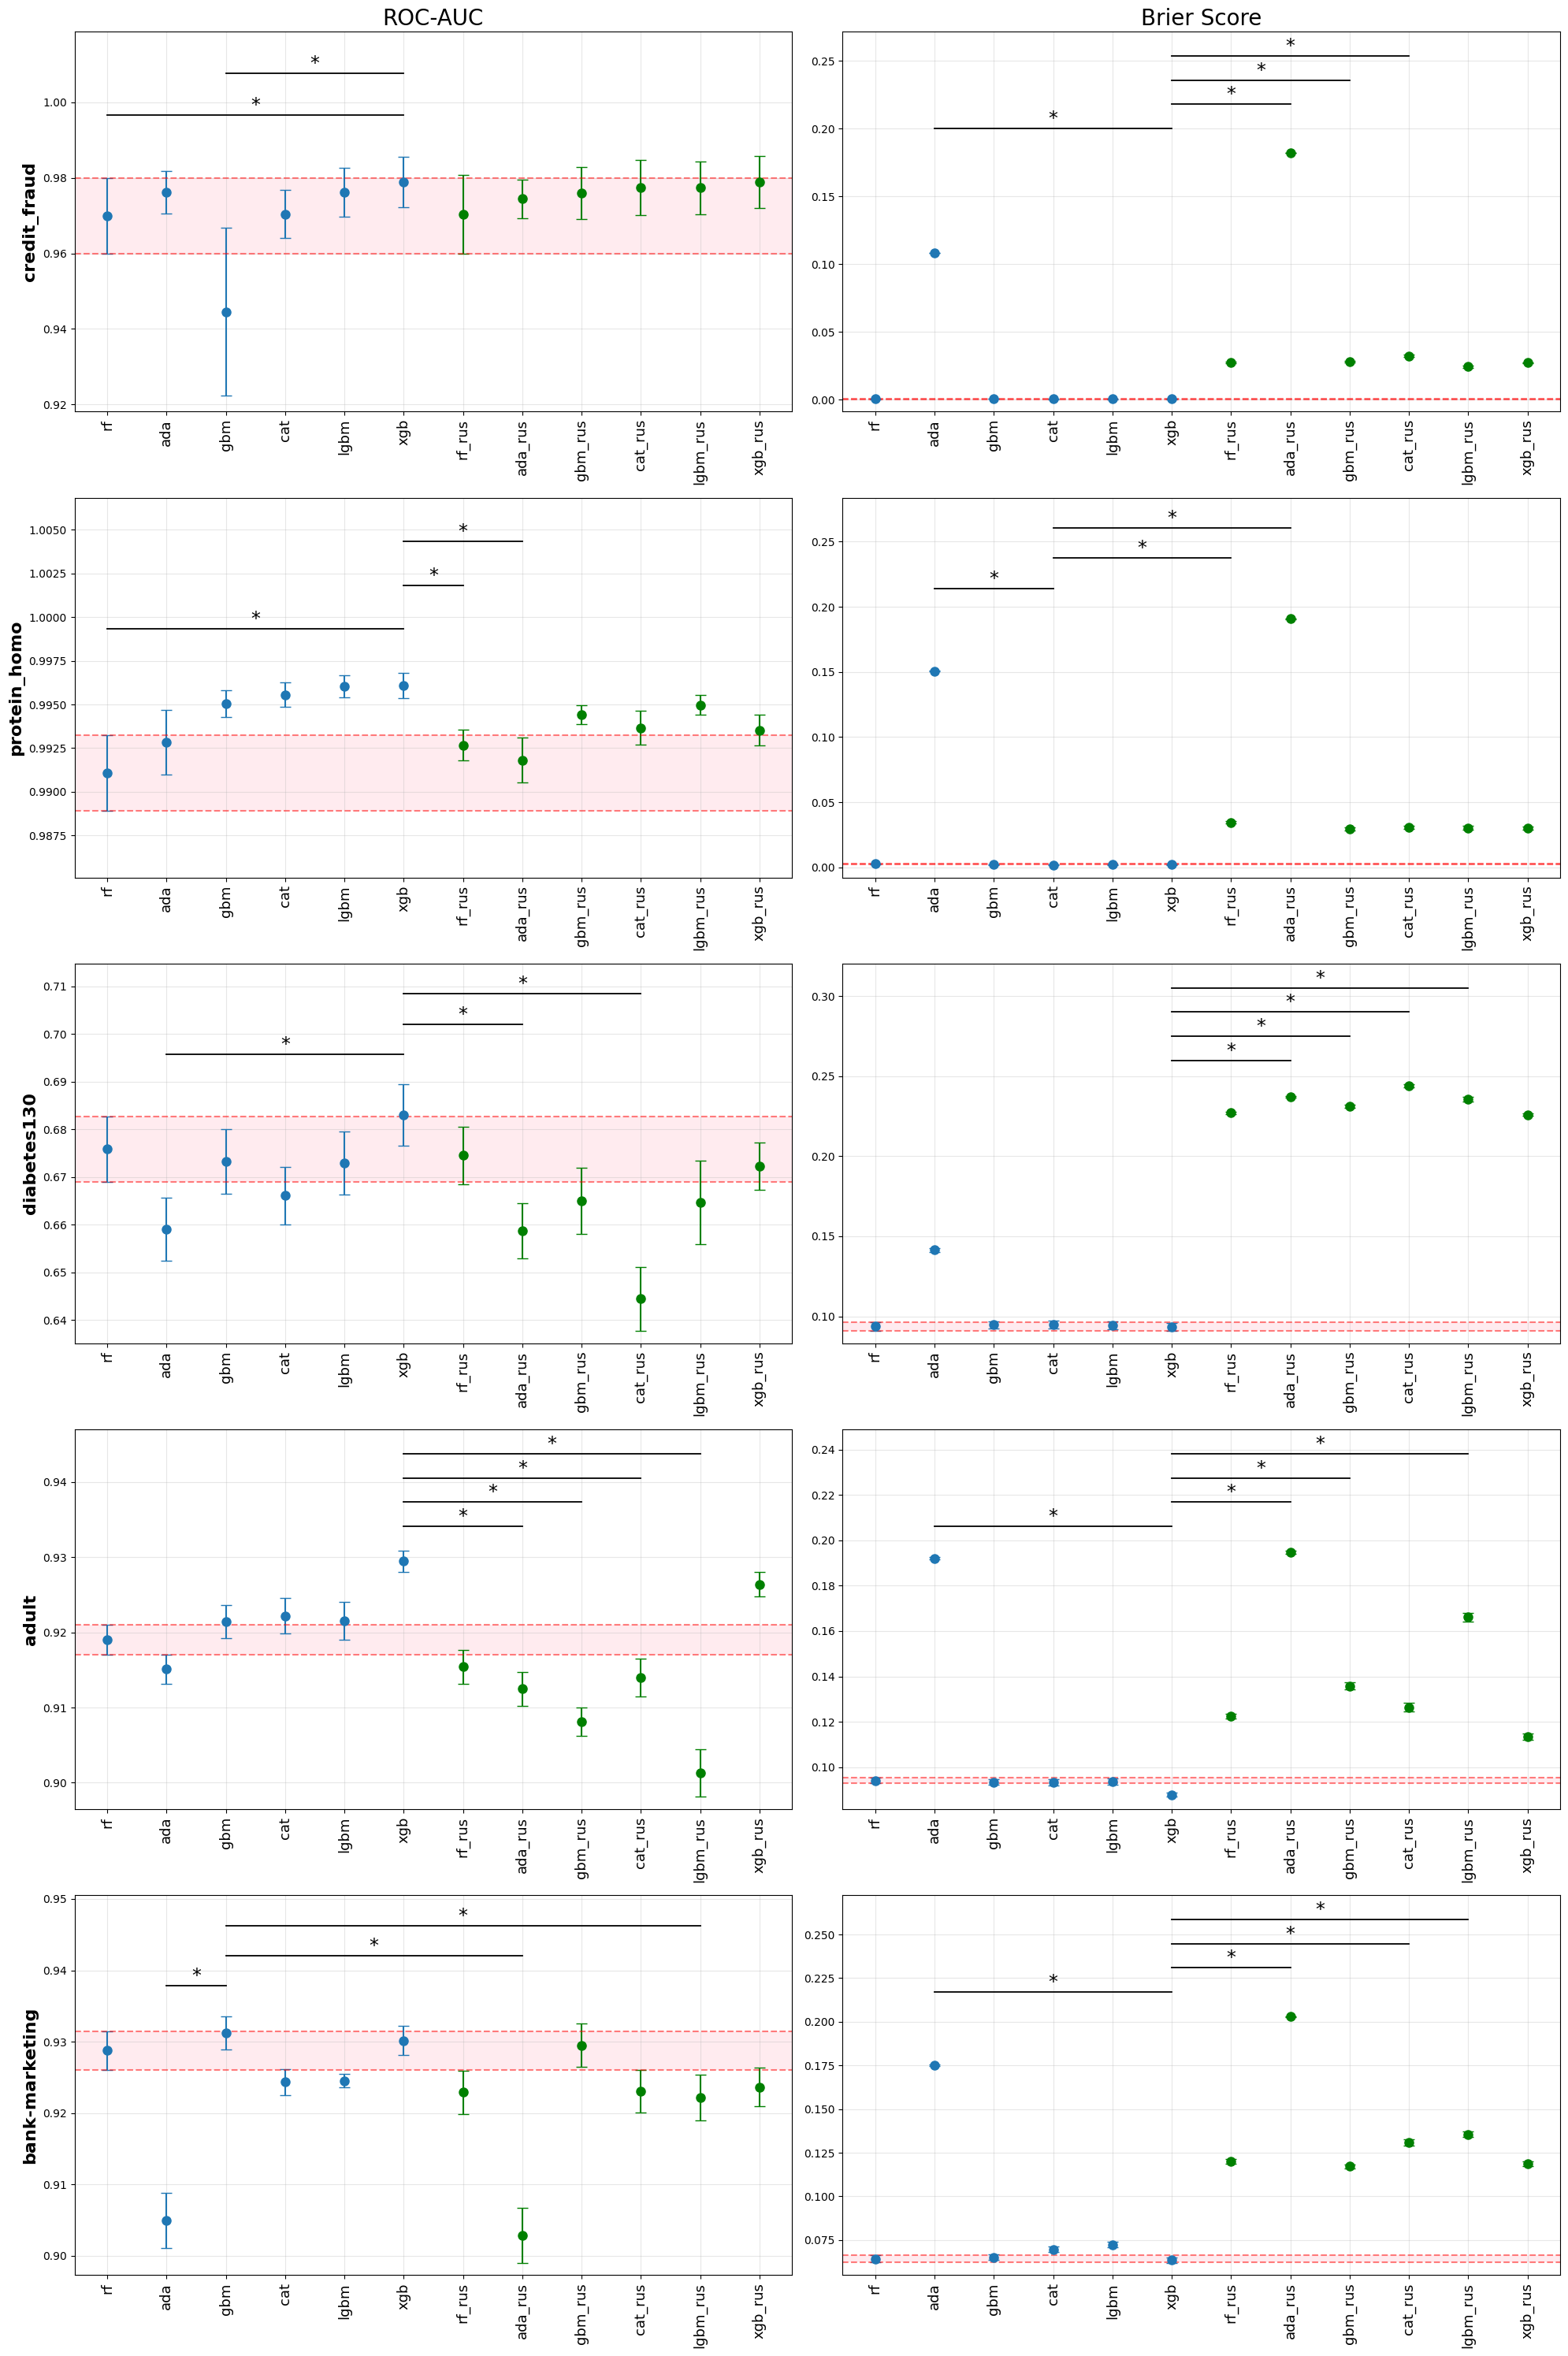

In [24]:
# One row per dataset. Column 0: ROC-AUC, column 1: Brier Score
fig, axes = plt.subplots(nrows=len(chapter5_datasets), ncols=2, figsize=(20, 6 * len(chapter5_datasets)))

metric_specs = [
    ("ROC-AUC", 0, 1, nemenyi_roc_rus, "max"),
    ("Brier Score", 14, 15, nemenyi_brier_rus, "min"),
]

for row, data in enumerate(chapter5_datasets):
    models = chapter5_models
    df = create_df(ch5_scores_dict, data, models)

    for col, (metric_name, col_mean, col_std, nemenyi_dict_metric, direction) in enumerate(metric_specs):
        ax = axes[row, col]

        cls = df.index
        means = df.iloc[:, col_mean]
        stds = df.iloc[:, col_std]
        is_rus = np.array([m.endswith("_rus") for m in cls])

        upper = df.iloc[0, col_mean] + df.iloc[0, col_std]
        lower = df.iloc[0, col_mean] - df.iloc[0, col_std]

        best_model = None
        sig_models = []
        if data in nemenyi_dict_metric:
            best_model = means.idxmax() if direction == "max" else means.idxmin()
            posthoc = nemenyi_dict_metric[data]
            sig_models = [
                m for m in models
                if m != best_model and posthoc.loc[best_model, m] < 0.05
            ]

        # original-distribution models in default color, RUS models in green
        ax.errorbar(x=cls[~is_rus], y=means[~is_rus], yerr=stds[~is_rus],
                    fmt='o', capsize=5, markersize=8, color='tab:blue')
        ax.errorbar(x=cls[is_rus], y=means[is_rus], yerr=stds[is_rus],
                    fmt='o', capsize=5, markersize=8, color='green')

        if col == 0:
            ax.set_ylabel(data, fontsize=16, fontweight="bold")
        if row == 0:
            ax.set_title(metric_name, fontsize=20)

        ylims = compute_ylim(means, stds, upper, lower)
        if sig_models:
            y0, y1 = ylims
            ylims = (y0, y1 + (y1 - y0) * 0.4)
        ax.set_ylim(ylims)
        ax.tick_params(axis='x', rotation=90, labelsize=13)
        ax.grid(True, alpha=0.3)

        ax.axhline(y=upper, color='r', linestyle='--', alpha=0.5)
        ax.axhline(y=lower, color='r', linestyle='--', alpha=0.5)
        ax.axhspan(ymin=lower, ymax=upper, facecolor='pink', alpha=0.3)

        if sig_models:
            data_max = (means + stds).max()
            add_significance_bars(ax, models, data_max, best_model, sig_models)

plt.tight_layout()
plt.savefig('../../mlid-book/resources/ch5/ch5-fig1.png', dpi=300, bbox_inches='tight')
plt.show()

### Balanced Accuracy & Threshold

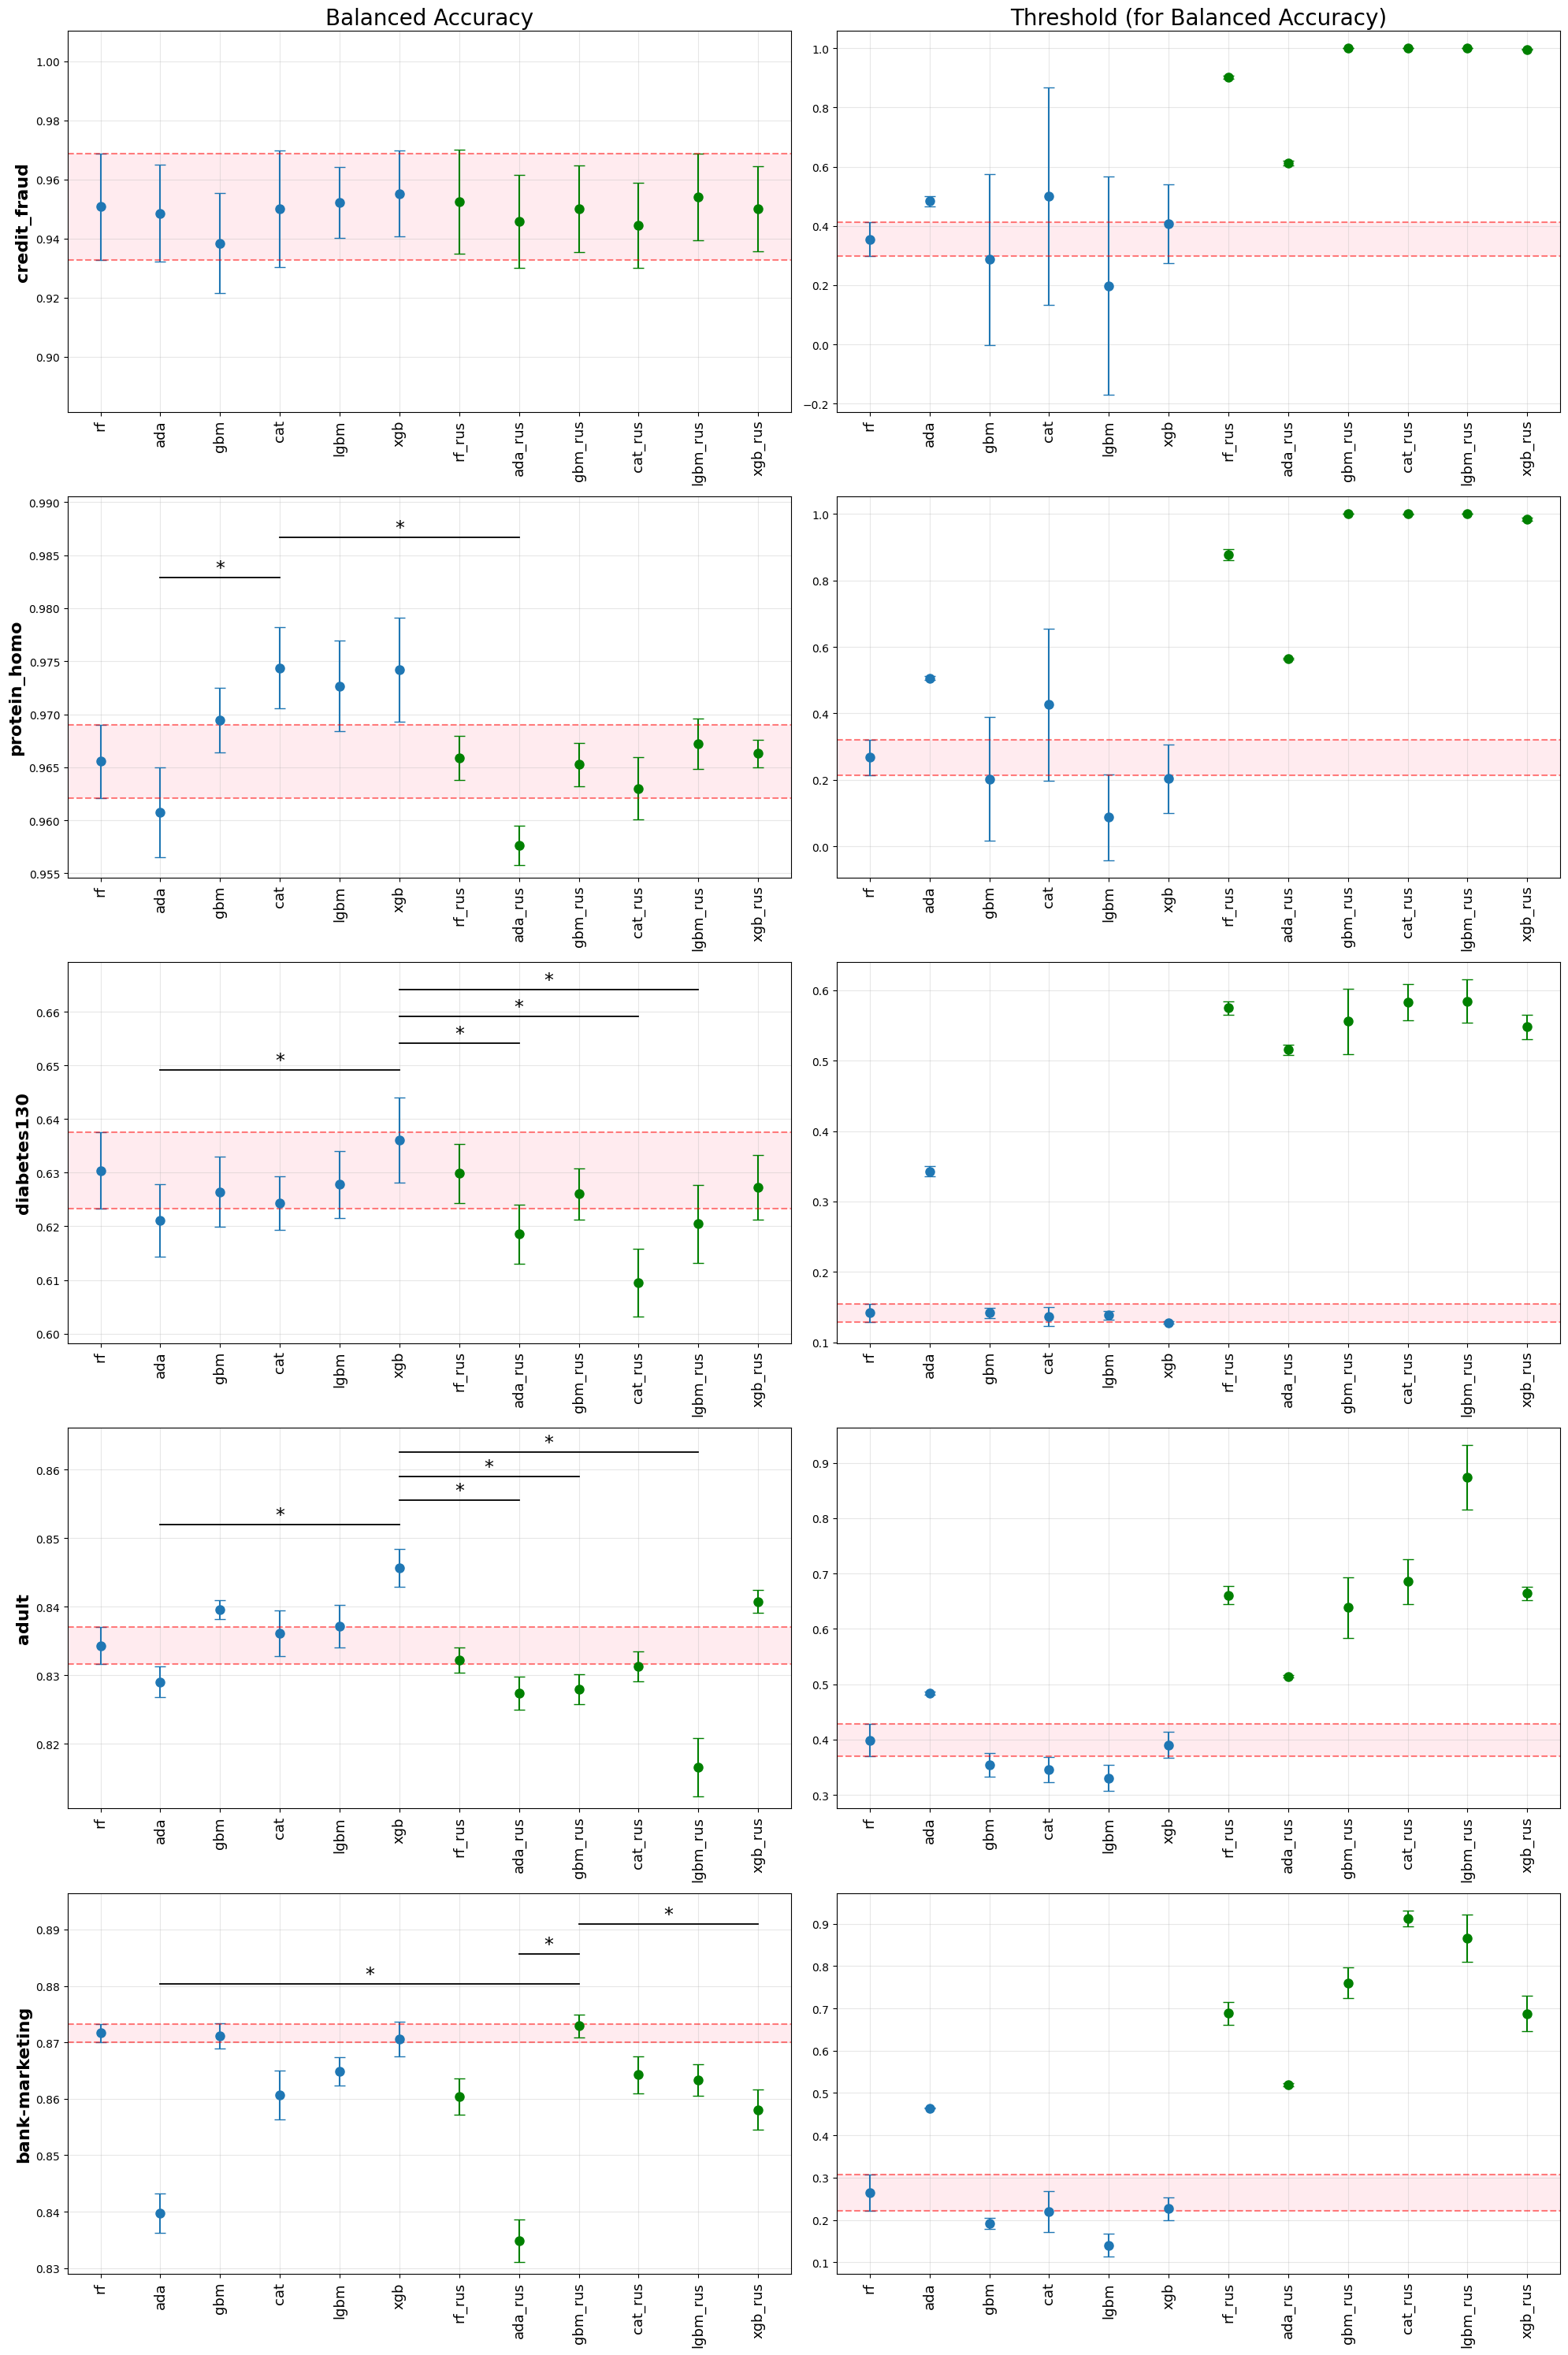

In [25]:
# One row per dataset. Column 0: Balanced Accuracy, column 1: threshold used for it.
# The threshold is an operating point, not a performance metric, so it has no
# "best" direction and is plotted without significance bars.
fig, axes = plt.subplots(nrows=len(chapter5_datasets), ncols=2, figsize=(20, 6 * len(chapter5_datasets)))

metric_specs = [
    ("Balanced Accuracy", 12, 13, nemenyi_ba_rus),
    ("Threshold (for Balanced Accuracy)", 18, 19, None),
]

for row, data in enumerate(chapter5_datasets):
    models = chapter5_models
    df = create_df(ch5_scores_dict, data, models)

    for col, (metric_name, col_mean, col_std, nemenyi_dict_metric) in enumerate(metric_specs):
        ax = axes[row, col]

        cls = df.index
        means = df.iloc[:, col_mean]
        stds = df.iloc[:, col_std]
        is_rus = np.array([m.endswith("_rus") for m in cls])

        upper = df.iloc[0, col_mean] + df.iloc[0, col_std]
        lower = df.iloc[0, col_mean] - df.iloc[0, col_std]

        best_model = None
        sig_models = []
        if nemenyi_dict_metric is not None and data in nemenyi_dict_metric:
            best_model = means.idxmax()
            posthoc = nemenyi_dict_metric[data]
            sig_models = [
                m for m in models
                if m != best_model and posthoc.loc[best_model, m] < 0.05
            ]

        # original-distribution models in default color, RUS models in green
        ax.errorbar(x=cls[~is_rus], y=means[~is_rus], yerr=stds[~is_rus],
                    fmt='o', capsize=5, markersize=8, color='tab:blue')
        ax.errorbar(x=cls[is_rus], y=means[is_rus], yerr=stds[is_rus],
                    fmt='o', capsize=5, markersize=8, color='green')

        if col == 0:
            ax.set_ylabel(data, fontsize=16, fontweight="bold")
        if row == 0:
            ax.set_title(metric_name, fontsize=20)

        ylims = compute_ylim(means, stds, upper, lower)
        if sig_models:
            y0, y1 = ylims
            ylims = (y0, y1 + (y1 - y0) * 0.4)
        ax.set_ylim(ylims)
        ax.tick_params(axis='x', rotation=90, labelsize=13)
        ax.grid(True, alpha=0.3)

        ax.axhline(y=upper, color='r', linestyle='--', alpha=0.5)
        ax.axhline(y=lower, color='r', linestyle='--', alpha=0.5)
        ax.axhspan(ymin=lower, ymax=upper, facecolor='pink', alpha=0.3)

        if sig_models:
            data_max = (means + stds).max()
            add_significance_bars(ax, models, data_max, best_model, sig_models)

plt.tight_layout()
plt.savefig('../../mlid-book/resources/ch5/ch5-fig2.png', dpi=300, bbox_inches='tight')
plt.show()

## Chapter 5: Cleaning methods

### Removed %

In [26]:
# bring in the other 9 undersampling methods compared in notebook
# 06-analysis-of-undersampling (ENN, RENN, AllKNN, Tomek, CNN, NCR, OSS)
subdirs = ['enn', 'renn', 'allknn', 'tomek', 'cnn', 'ncr', 'oss']
base_dir = '../models'

for subdir in subdirs:
    with open(f'{base_dir}/{subdir}/results', 'rb') as f:
        tmp_scores = pickle.load(f)
    with open(f'{base_dir}/{subdir}/results_folds', 'rb') as f:
        tmp_folds = pickle.load(f)

    ch5_scores_dict = {
        dataset: {**ch5_scores_dict[dataset], **tmp_scores[dataset]}
        for dataset in ch5_scores_dict
    }
    ch5_folds_dict = {
        dataset: {**ch5_folds_dict[dataset], **tmp_folds[dataset]}
        for dataset in ch5_folds_dict
    }

# the 9 cleaning-based undersamplers
us_methods = subdirs

all_stats = {}
for method in us_methods:
    with open(f'{base_dir}/{method}/sampling_stats', 'rb') as f:
        all_stats[method] = pickle.load(f)


def active_models(dataset):
    """Baseline + undersampling variants that actually removed rows for this
    dataset (0% removal leaves the model identical to baseline)."""
    active = list(base_models)
    for method in us_methods:
        if all_stats[method][dataset]['removed_pct'] > 0:
            active += [f"{b}_{method}" for b in base_models]
    return active

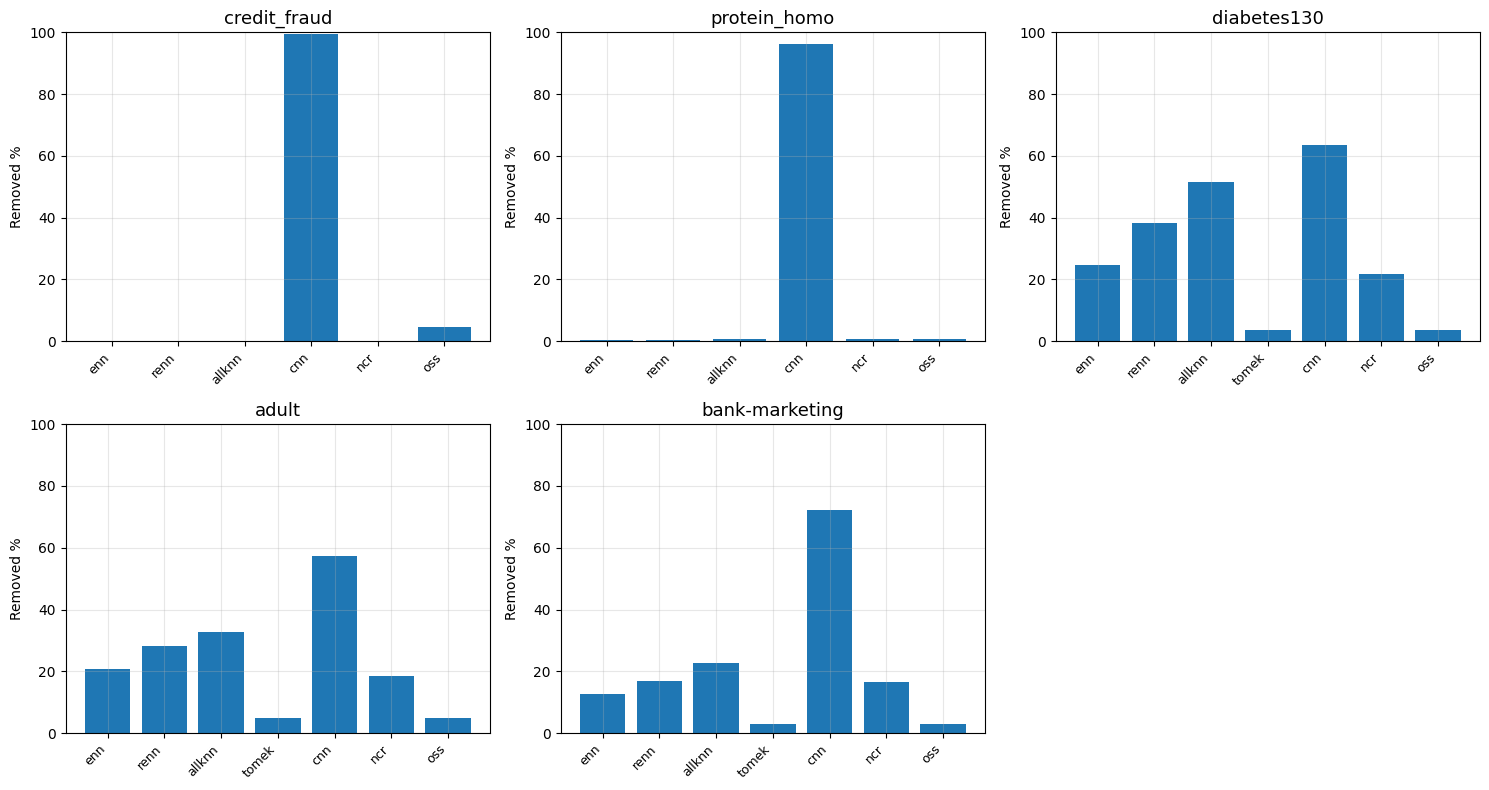

In [27]:
# Percentage of training samples removed by each undersampling method,
# per dataset. 5 datasets: 3 in row 1, 2 in row 2.
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
axes = axes.ravel()

for i, data in enumerate(chapter5_datasets):
    ax = axes[i]
    values = pd.Series({m: all_stats[m][data]['removed_pct'] for m in us_methods})
    # drop methods that removed no rows for this dataset
    values = values[values > 0]
    ax.bar(values.index, values)
    ax.set_title(data, fontsize=13)
    ax.set_ylim(0, 100)
    ax.set_ylabel('Removed %')
    ax.set_xticks(range(len(values)))
    ax.set_xticklabels(values.index, rotation=45, ha='right', fontsize=9)
    ax.grid(True, alpha=0.3)

# hide the unused 6th panel
for j in range(len(chapter5_datasets), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('../../mlid-book/resources/ch5/ch5-fig3.png', dpi=300, bbox_inches='tight')
plt.show()

### ROC-AUC

In [28]:
# Friedman + Nemenyi tests for ROC-AUC, restricted per dataset to the baseline
# models plus whichever undersampling variants actually removed rows
nemenyi_dict_us_roc = {}

for data in chapter5_datasets:
    m = active_models(data)
    fold_df = create_fold_df(ch5_folds_dict, data, "roc")[m]
    statistic, pvalue = apply_friedman_test(fold_df)
    if pvalue < 0.05:
        nemenyi_dict_us_roc[data] = apply_nemenyi_test(fold_df)

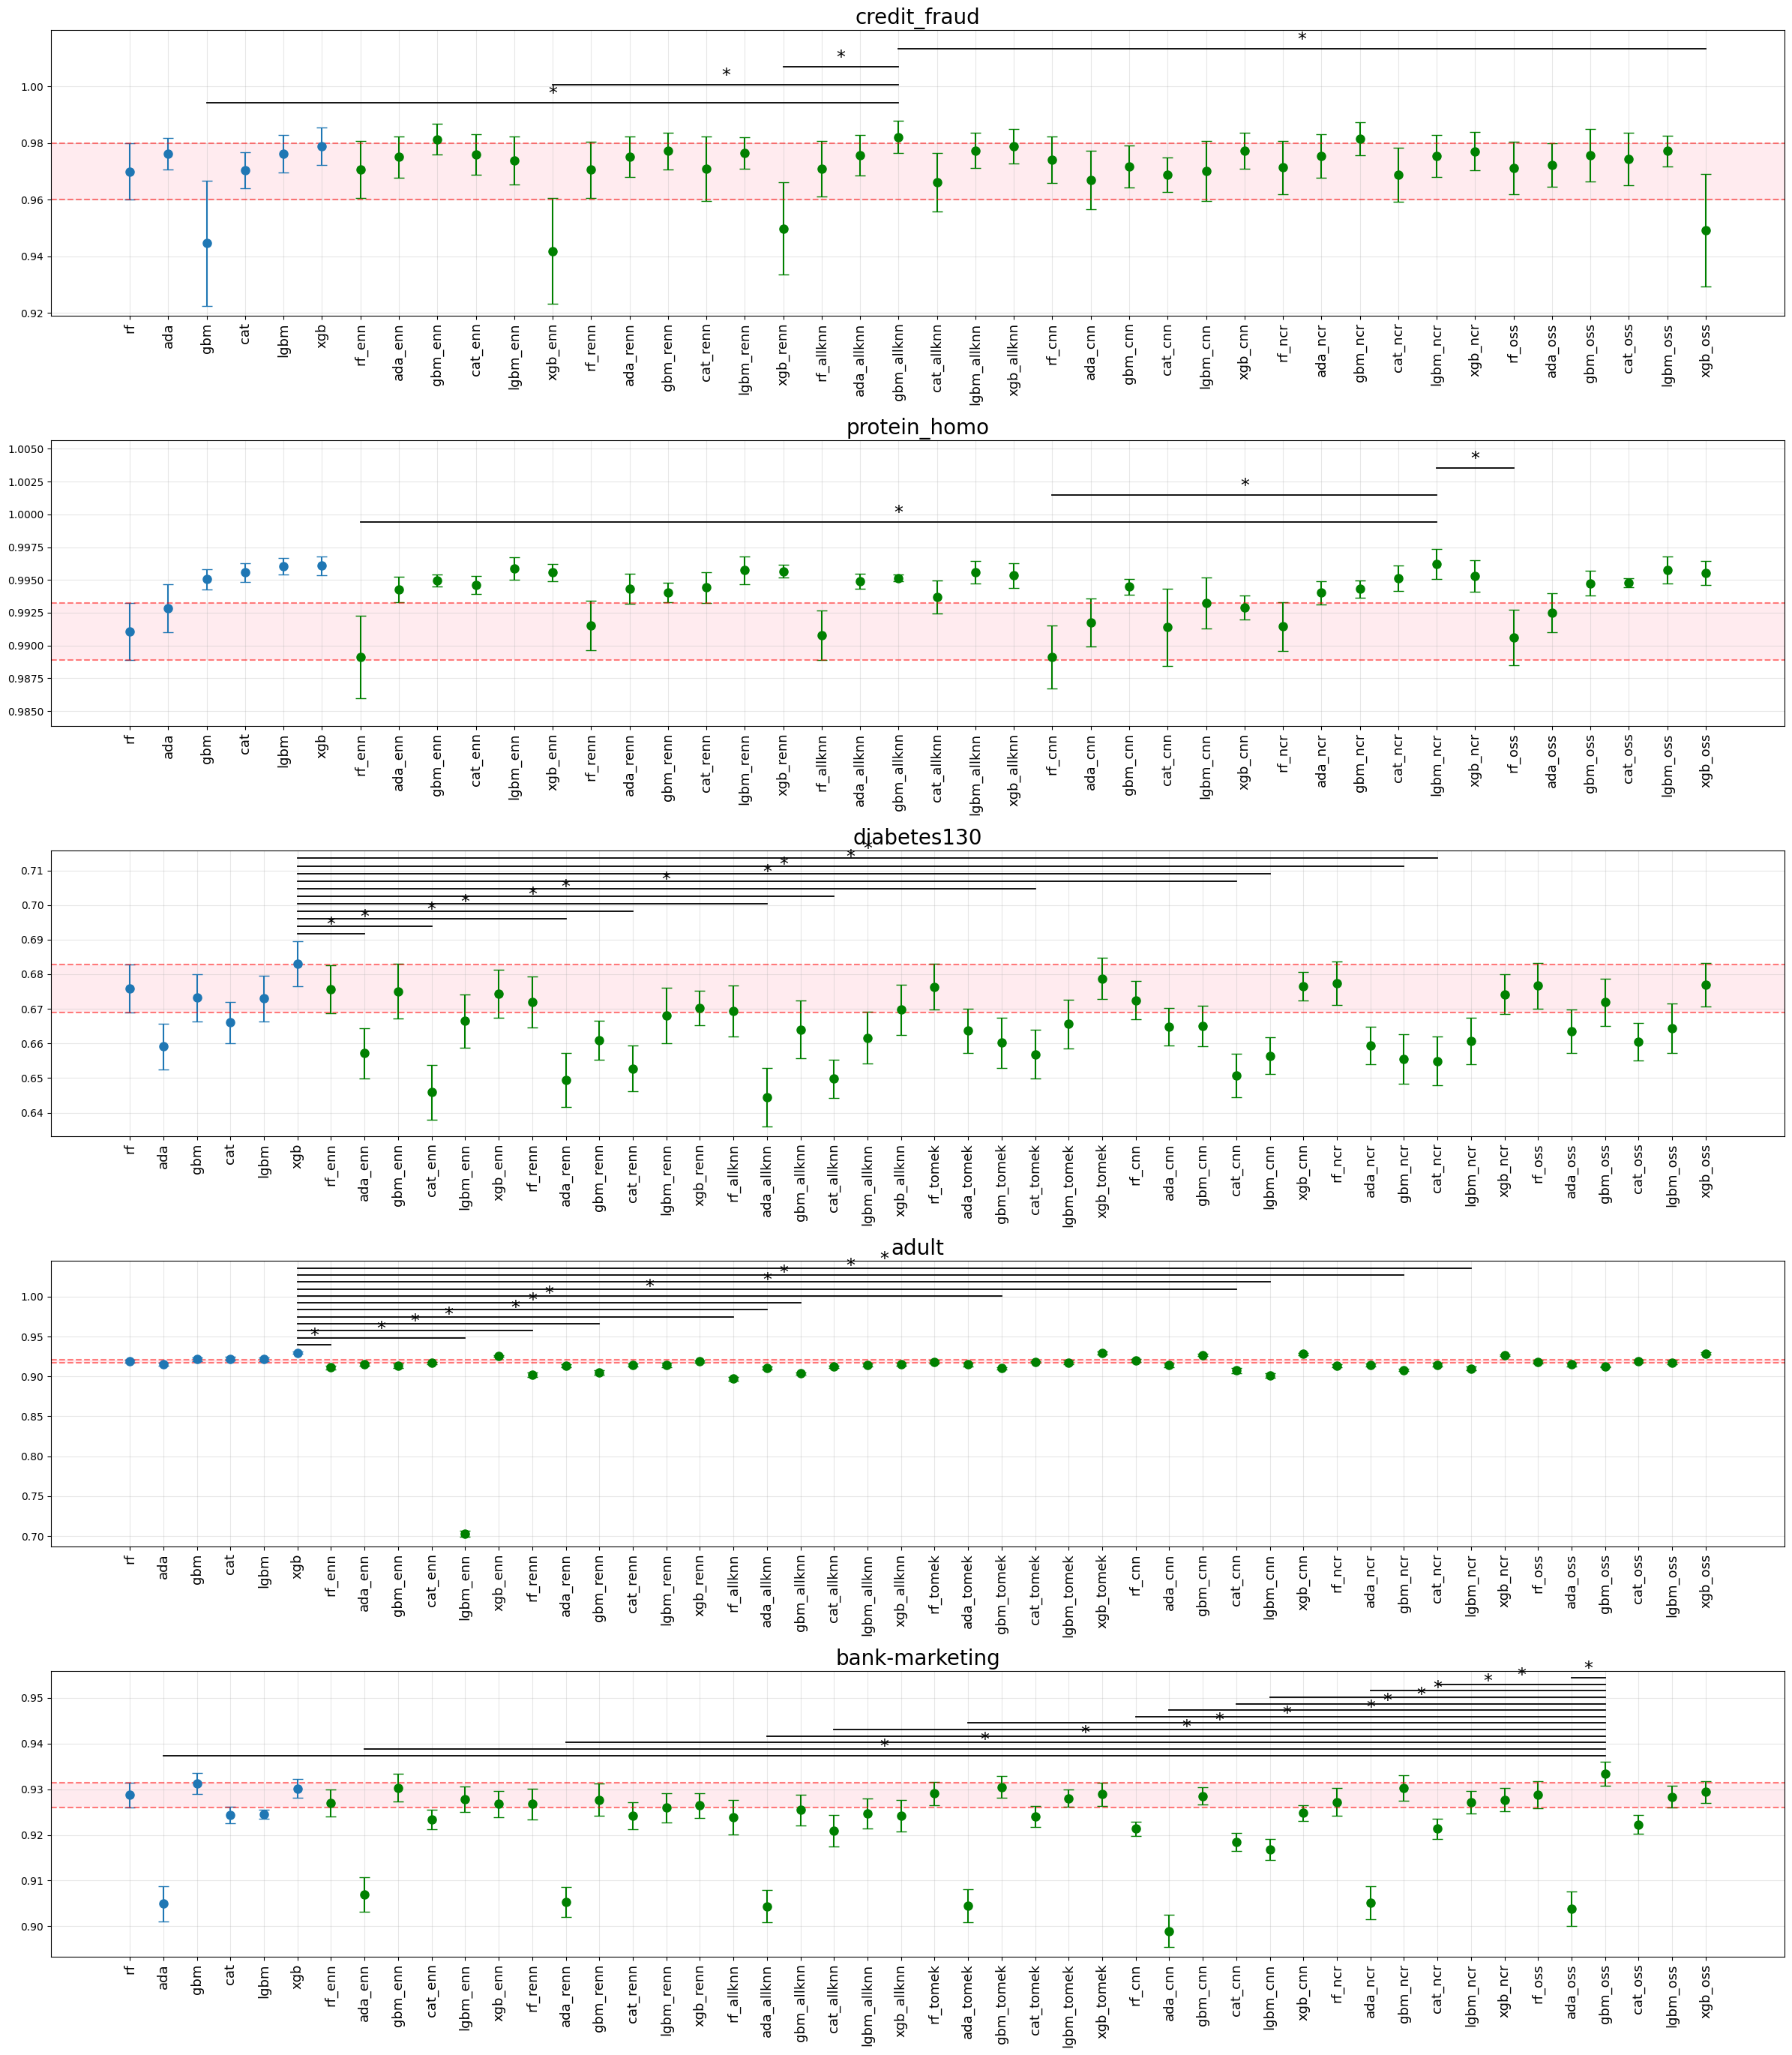

In [29]:
# ROC-AUC across baseline + all active undersampling methods, one dataset per row
fig, axes = plt.subplots(nrows=len(chapter5_datasets), ncols=1, figsize=(24, 5.5 * len(chapter5_datasets)))

for i, data in enumerate(chapter5_datasets):
    m = active_models(data)
    df = create_df(ch5_scores_dict, data, m)
    ax = axes[i]

    means = df.iloc[:, 0]
    stds = df.iloc[:, 1]
    upper = df.iloc[0, 0] + df.iloc[0, 1]
    lower = df.iloc[0, 0] - df.iloc[0, 1]

    base_m = [x for x in m if x in base_models]
    us_m = [x for x in m if x not in base_models]

    best_model = None
    sig_models = []
    if data in nemenyi_dict_us_roc:
        best_model = means.idxmax()
        posthoc = nemenyi_dict_us_roc[data]
        sig_models = [
            x for x in m
            if x != best_model and posthoc.loc[best_model, x] < 0.05
        ]

    # baseline in default color, undersampled variants in green
    ax.errorbar(x=base_m, y=means[base_m], yerr=stds[base_m],
                fmt='o', capsize=5, markersize=8, color='tab:blue')
    ax.errorbar(x=us_m, y=means[us_m], yerr=stds[us_m],
                fmt='o', capsize=5, markersize=8, color='green')

    ax.set_title(data, fontsize=20)
    ylims = compute_ylim(means, stds, upper, lower)
    if sig_models:
        y0, y1 = ylims
        ylims = (y0, y1 + (y1 - y0) * 0.4)
    ax.set_ylim(ylims)
    ax.tick_params(axis='x', rotation=90, labelsize=13)
    ax.grid(True, alpha=0.3)

    ax.axhline(y=upper, color='r', linestyle='--', alpha=0.5)
    ax.axhline(y=lower, color='r', linestyle='--', alpha=0.5)
    ax.axhspan(ymin=lower, ymax=upper, facecolor='pink', alpha=0.3)

    if sig_models:
        data_max = (means + stds).max()
        add_significance_bars(ax, m, data_max, best_model, sig_models)

plt.tight_layout()
plt.savefig('../../mlid-book/resources/ch5/ch5-fig4.png', dpi=300, bbox_inches='tight')
plt.show()